# Neutron Star Mass Distributions

This notebook fits mass distributions to different sub-sets of neutron star data. In particular, we use either a uniform, single gaussian, or double gaussian model with uniform priors on galactic double neutron stars, Gaia neutron stars, and neutron stars in binaries with white dwarves.

In [65]:
import jax.numpy as jnp
import jax.random as random
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, log_likelihood, SA
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
import corner
import pandas as pd

import seaborn as sns
sns.set_context("paper", font_scale=1.5)


# Model Functions

In [66]:
priormin = 0.0
priormax = 2.1

In [67]:
def gaussian_uniform(data, err, prior=False):
    """
    Single Gaussian model with uniform priors.

    Parameters:
        data : array-like
            Observed data.
        err : array-like
            Observed errors.
        prior : bool
            If True, only sample from the prior distribution.
    """
    mu = numpyro.sample('mu', dist.Uniform(priormin, priormax))
    sigma = numpyro.sample('sigma', dist.Uniform(priormin, priormax))
    
    if not prior:
        numpyro.sample('obs', dist.Normal(mu, jnp.sqrt(sigma**2 + err**2)), obs=data)

def double_gaussian_uniform(data, err, prior=False):
    """
    Double Gaussian model with uniform priors.
    
    Parameters:
        data : array-like
            Observed data.
        err : array-like
            Observed errors.
        prior : bool
            If True, only sample from the prior distribution.
    """
    mu1 = numpyro.sample('mu1', dist.Uniform(priormin, priormax))
    mu2 = numpyro.sample('mu2', dist.Uniform(mu1, priormax))
    sigma1 = numpyro.sample('sigma1', dist.Uniform(priormin,priormax))
    sigma2 = numpyro.sample('sigma2', dist.Uniform(priormin, priormax))
    weight = numpyro.sample('weight', dist.Uniform(0, 1)) 

    if not prior:
        scale1 = jnp.sqrt(sigma1**2 + err**2)
        scale2 = jnp.sqrt(sigma2**2 + err**2)

        logp1 = dist.Normal(mu1, scale1).log_prob(data)
        logp2 = dist.Normal(mu2, scale2).log_prob(data)

        log_mix = jnp.logaddexp(jnp.log(weight) + logp1,
                                jnp.log1p(-weight) + logp2)
        numpyro.factor("obs", jnp.sum(log_mix))

        log_L = numpyro.deterministic("log_L", log_mix)

In [68]:
def run_inference(model, data, err, rng_key, num_warmup=10000, num_samples=10000):
    """
    Run MCMC inference using the NUTS sampler.  

    Parameters:
        model : callable
            The mass distribution model to sample from.
        data : array-like
            Observed data.
        err : array-like
            Observed errors.
        rng_key : jax.random.PRNGKey
            Random key for JAX.
        num_warmup : int
            Number of warmup samples.
        num_samples : int
            Number of samples to draw from the posterior.
    Returns:
        mcmc : MCMC
            The MCMC object containing the samples.
    """
    kernel = NUTS(model)
    mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples)
    mcmc.run(rng_key, data=data, err=err)
    return mcmc

In [69]:
def plot_mass_distributions(mcmc, model_type, data, label):
    """
    Plots the inferred mass distributions of the parameters.

    Parameters:
        mcmc: MCMC object containing posterior samples.
        model_type: Type of model used ("single" or "double").
        data: The observed data used to define the x-axis range.
        label: Label for the plot.

    Returns:
        Plots of the inferred mass distributions.
    """
    samples = mcmc.get_samples()
    x = np.linspace(min(data) - 0.2, max(data) + 0.2, 1000)

    plt.figure(figsize=(8, 5))

    if model_type == "single":
        mu = samples['mu']
        sigma = samples['sigma']
        for i in np.random.choice(len(mu), 100, replace=False):
            y = scipy.stats.norm.pdf(x, loc=mu[i], scale=sigma[i])  
            plt.plot(x, y, alpha=0.1, color='C0')
    
    elif model_type == "double":
        mu1 = samples['mu1']
        mu2 = samples['mu2']
        sigma1 = samples['sigma1']
        sigma2 = samples['sigma2']
        weight = samples['weight']

        for i in np.random.choice(len(mu1), 100, replace=False):
            w = weight[i]
            y = (
                w * scipy.stats.norm.pdf(x, loc=mu1[i], scale=sigma1[i]) + 
                (1 - w) * scipy.stats.norm.pdf(x, loc=mu2[i], scale=sigma2[i])  
            )
            plt.plot(x, y, alpha=0.1, color='C1')

    plt.xlabel(r"Mass [$M_\odot$]")
    plt.ylabel("PDF")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Load in Data

In [70]:
data = pd.read_csv("NS_data.csv")

DNS = data[data['type'] == 'NS-NS'] # Double neutron star, 'm1' is the recycled neutron star and 'm2' is the slow neutron star
Gaia = data[data['type'] == 'Gaia'] 
NSWD = data[data['type'] == 'NS-WD']

In [154]:
# Select the columns you want to display (add or remove as needed)


# Concatenate and reset index
combined = pd.concat([DNS, Gaia], ignore_index=True)
pd.set_option('display.max_columns', None)  # Show all columns

# Print the combined table
print(combined)
combined.to_csv("our_NS_data.csv", index=False)

    Unnamed: 0.1  Unnamed: 0         Name      m1  m1_uerr  m1_lerr      m2  \
0             49        49.0   J1411+2551     NaN      NaN      NaN     NaN   
1             50        50.0   J1946+2052     NaN      NaN      NaN     NaN   
2             51        51.0   J1518+4904  1.4100   0.0800   0.0800  1.3100   
3             52        52.0   J1930-1852     NaN      NaN      NaN     NaN   
4             53        53.0    B2127+11C  1.3580   0.0100   0.0100  1.3540   
5             54        54.0     B1534+12  1.3330   0.0002   0.0002  1.3455   
6             55        55.0   J1811-1736     NaN      NaN      NaN     NaN   
7             56        56.0   J1913+1102  1.6200   0.0300   0.0300  1.2700   
8             57        57.0   J1759+5036     NaN      NaN      NaN     NaN   
9             58        58.0  J1807-2500B  1.3655   0.0021   0.0021  1.2064   
10            59        59.0     B1913+16  1.4398   0.0002   0.0002  1.3886   
11            60        60.0   J1018-1523     NaN   

In [71]:
gaia_data = np.array(Gaia['m1'])  
gaia_data_err = np.array(Gaia[['m1_uerr', 'm1_lerr']].max(axis=1).dropna())  

DNS_data = DNS['m1'].dropna().to_numpy()
DNS_data_err = DNS[['m1_uerr', 'm1_lerr']].max(axis=1).dropna().to_numpy()

NSWD_data =  NSWD['m1'].dropna().to_numpy()
NSWD_data_err =NSWD[['m1_uerr', 'm1_lerr']].max(axis=1).dropna().to_numpy()


def plot_cdf(m, uerr, lerr):
    """
    Returns useful arrays to plot the cumulative distribution function (CDF) of the mass distribution.  
    Parameters:
        m : array-like
            Mass values.
        uerr : array-like
            Upper errors.
        lerr : array-like
            Lower errors.

    Returns:
        masses : array-like
            Sorted mass values.
        uerrors : array-like
            Sorted upper errors.
        lerrors : array-like
            Sorted lower errors.
        bins : list
            List of bins for the histogram.
    """

    sorted_idx = np.argsort(m)
    masses = m[sorted_idx] 
    uerrors = uerr[sorted_idx]
    lerrors = lerr[sorted_idx]
    
    masses = masses[~np.isnan(masses)]
    uerrors = uerrors[~np.isnan(uerrors)]
    lerrors = lerrors[~np.isnan(lerrors)]

    bins = list(masses)
    bins.append(max(masses))
    bins.insert(0,0)
    
    return(masses, uerrors, lerrors, bins)

/var/folders/by/tlp8gdq17q72kgysbfmtlzp40000gn/T/ipykernel_60817/351942376.py:39: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['Name'][data['Name']=='J0737-3039A'] = data['Name'][data['Name']=='J0737-3039A'].str.replace("A", "", regex=

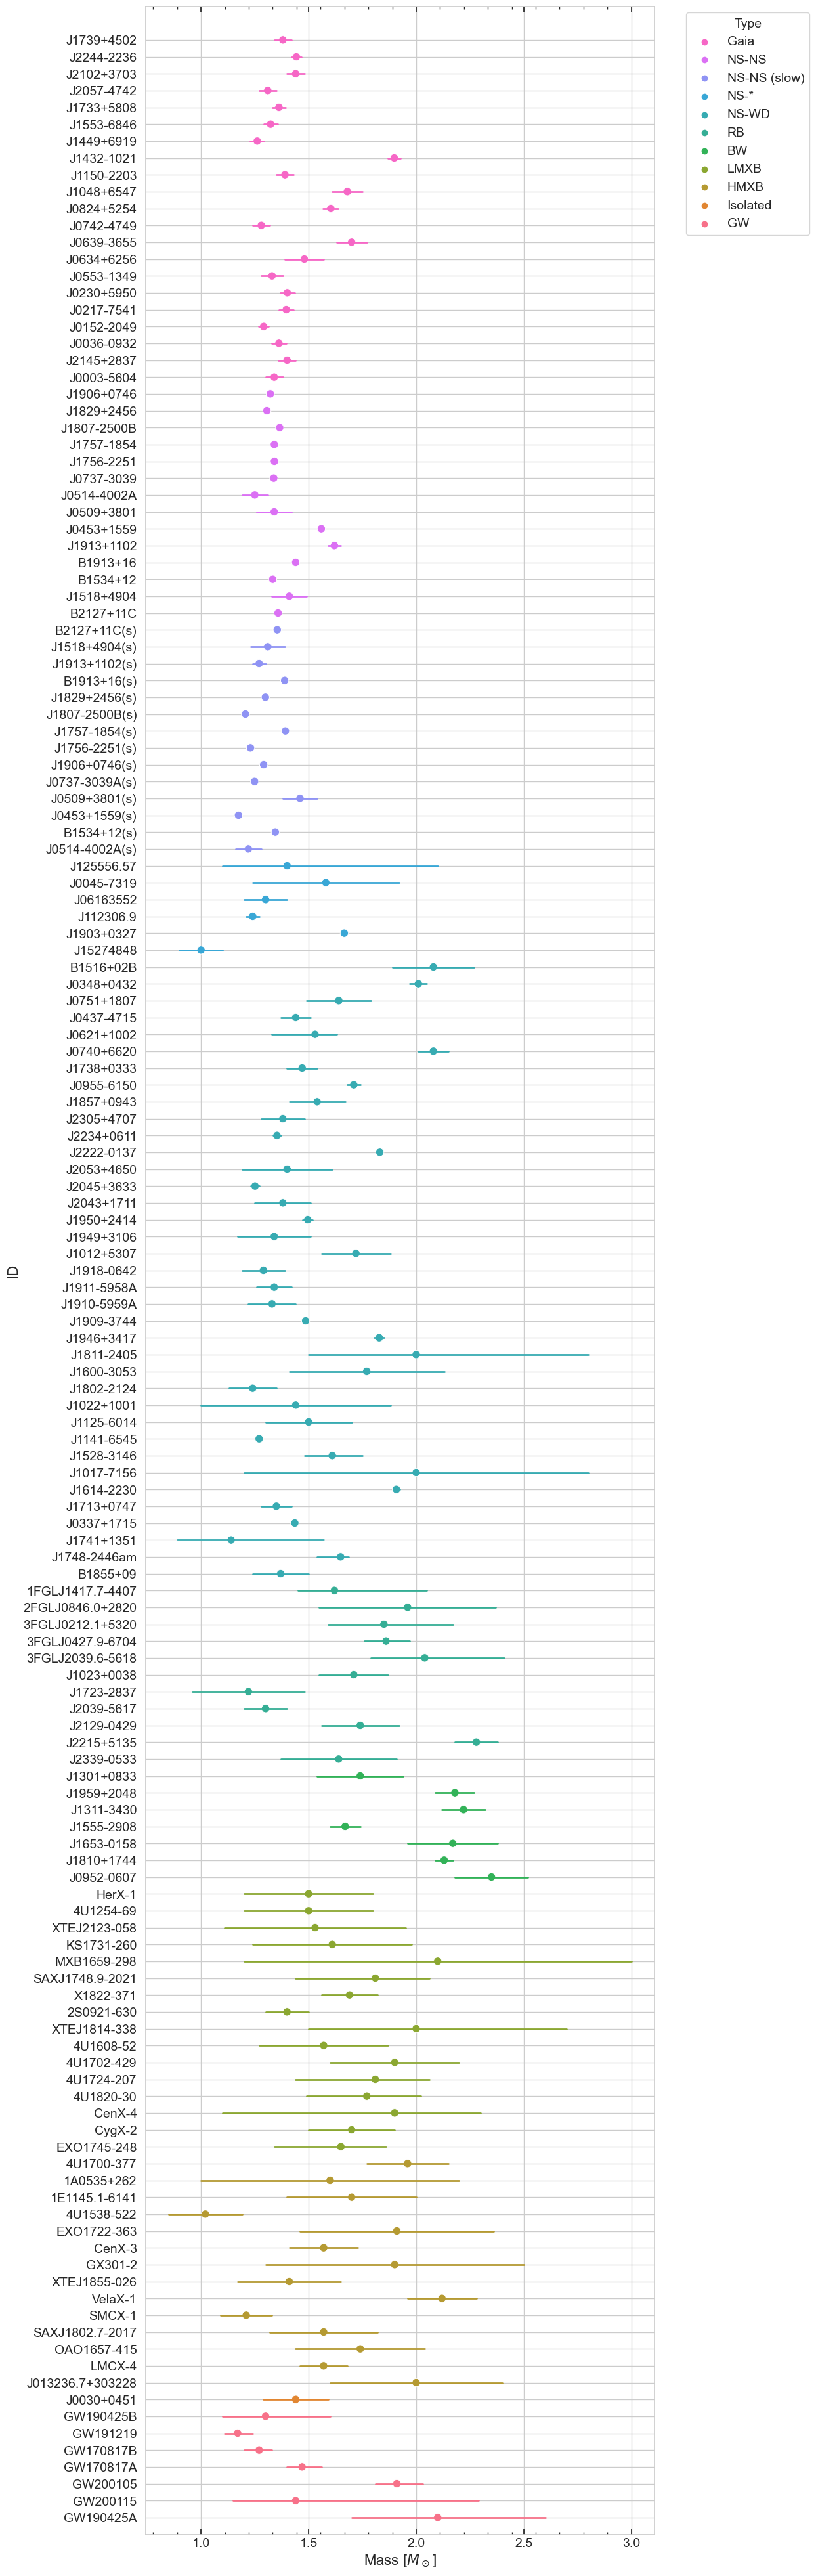

In [111]:
import matplotlib.ticker as ticker


# Ensure numeric columns are converted properly
data['m1'] = pd.to_numeric(data['m1'], errors='coerce')
data['m1_uerr'] = pd.to_numeric(data['m1_uerr'], errors='coerce')
data['m1_lerr'] = pd.to_numeric(data['m1_lerr'], errors='coerce')

data['m2'] = pd.to_numeric(data['m2'], errors='coerce')
data['m2_uerr'] = pd.to_numeric(data['m2_uerr'], errors='coerce')
data['m2_lerr'] = pd.to_numeric(data['m2_lerr'], errors='coerce')

# Compute asymmetric error bars
data['m1_err_lower'] = data['m1'] - np.abs(data['m1_lerr'])
data['m1_err_upper'] = np.abs(data['m1_uerr']) + data['m1']

data['m2_err_lower'] = data['m2'] - np.abs(data['m2_lerr'])
data['m2_err_upper'] = np.abs(data['m2_uerr']) + data['m2']

# Create new rows for `m2`
extra_rows = data[data['type'].isin(['NS-NS'])].copy()
extra_rows['Name'] = extra_rows['Name'] + "(s)"
extra_rows['m1'] = extra_rows['m2']
extra_rows['m1_err_lower'] = extra_rows['m2_err_lower']
extra_rows['m1_err_upper'] = extra_rows['m2_err_upper']
extra_rows['type'] = 'NS-NS (slow)'

# Append the modified rows
data = pd.concat([data, extra_rows]).sort_values(["type",'Name'], ascending=False)

extra_rows = data[(data['type'] == 'GW') & (data['m2'].notna())].copy()
extra_rows['Name'] = extra_rows['Name'].str.replace("A", "", regex=False) + "B"
extra_rows['m1'] = extra_rows['m2']
extra_rows['m1_err_lower'] = extra_rows['m2_err_lower']
extra_rows['m1_err_upper'] = extra_rows['m2_err_upper']

data = pd.concat([data, extra_rows]).sort_values(["type",'Name'], ascending=False)

data['Name'][data['Name']=='J0737-3039A'] = data['Name'][data['Name']=='J0737-3039A'].str.replace("A", "", regex=False)
rows_to_drop = data[data['m1'].isna()]

data = data.dropna(subset=['m1'])

### Sort in the order I want it plotted
custom_order = np.flip(['Gaia', 'NS-NS', 'NS-NS (slow)', 'NS-*', 'NS-WD', 'RB', 'BW', 'LMXB', 'HMXB', 'Isolated', 'GW'])
data['type'] = pd.Categorical(data['type'], categories=custom_order, ordered=True)
data = data.sort_values('type')

# Set plot style
sns.set_context("paper")
sns.set(style="whitegrid")

# Create the figure
fig, ax = plt.subplots(figsize=(10, 50))

# Create the scatter plot
sns.scatterplot(
    x="m1", y="Name", hue="type", data=data, palette="husl", s=80, ax=ax, hue_order=custom_order,
)

# Get colors assigned by seaborn
colors = {t: c for t, c in zip(custom_order, sns.color_palette("husl", n_colors=len(custom_order)))}

# Add error bars manually with matching colors
for i in range(len(data)):
    ax.plot(
        [data["m1_err_lower"].iloc[i], data["m1_err_upper"].iloc[i]],
        [data["Name"].iloc[i], data["Name"].iloc[i]],
        color=colors[data["type"].iloc[i]],  # Match color of data point
        linewidth=2)


# Labels
ax.set_xlabel("Mass [$M_\\odot$]", fontsize=16)
ax.set_ylabel("ID", fontsize=16)

# Adjust y-axis limits
ax.set_ylim(-1, len(data) + 1)  # Trim empty space above and below

# Enable ticks on both top and bottom
ax.xaxis.set_ticks_position('both')  # Show ticks at both top and bottom
ax.tick_params(axis='x', which='both', direction='in', length=6)  # Major ticks inwards

# Add minor ticks
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1 / 9))   # Auto minor ticks
ax.tick_params(axis='x', which='minor', direction='in', length=3)  # Minor ticks inwards

# Make axis text larger
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

# Adjust legend
#plt.legend(title="Type", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, title_fontsize=14)
handles, labels = ax.get_legend_handles_labels()

# Remove the automatic legend
ax.legend_.remove()

# Add the legend back, but flipped
ax.legend(
    handles[::-1], labels[::-1],  
    title="Type",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=14,
    title_fontsize=14
)
# Show plot
plt.show()

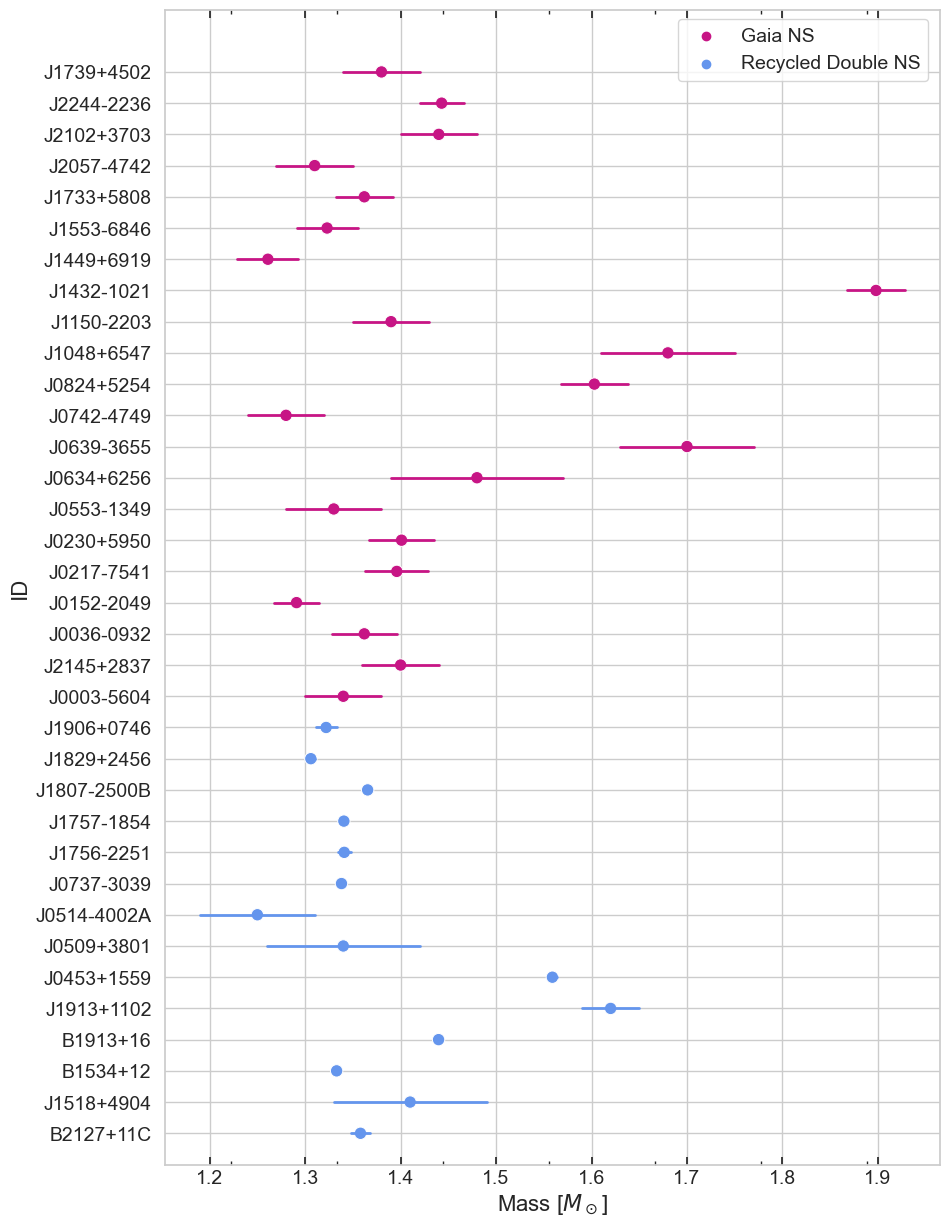

In [150]:
# Select only the types you want to plot
types_to_plot = ['Gaia', 'NS-NS']  # <-- change this list as needed
filtered_data = data[data['type'].isin(types_to_plot)]

# Update custom_order to match only the types you want to plot
custom_order = np.flip(types_to_plot)
custom_palette = {
    "Gaia": "mediumvioletred",
    "NS-NS": "cornflowerblue"
}

fig, ax = plt.subplots(figsize=(10, 15))

# Create the scatter plot
sns.scatterplot(
    x="m1", y="Name", hue="type", data=filtered_data,
    palette=custom_palette, s=80, ax=ax, hue_order=custom_order,
)

# Get colors assigned by seaborn (now matches your custom_palette)
colors = custom_palette

# Add error bars manually with matching colors
for i in range(len(filtered_data)):
    ax.plot(
        [filtered_data["m1_err_lower"].iloc[i], filtered_data["m1_err_upper"].iloc[i]],
        [filtered_data["Name"].iloc[i], filtered_data["Name"].iloc[i]],
        color=colors[filtered_data["type"].iloc[i]],  # Match color of data point
        linewidth=2)


# Labels
ax.set_xlabel("Mass [$M_\\odot$]", fontsize=16)
ax.set_ylabel("ID", fontsize=16)

# Adjust y-axis limits
ax.set_ylim(-1, len(filtered_data) + 1)  # Trim empty space above and below

# Enable ticks on both top and bottom
ax.xaxis.set_ticks_position('both')  # Show ticks at both top and bottom
ax.tick_params(axis='x', which='both', direction='in', length=6)  # Major ticks inwards

# Add minor ticks
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1 / 9))   # Auto minor ticks
ax.tick_params(axis='x', which='minor', direction='in', length=3)  # Minor ticks inwards

# Make axis text larger
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

# Adjust legend
#plt.legend(title="Type", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, title_fontsize=14)
handles, labels = ax.get_legend_handles_labels()

# Remove the automatic legend
ax.legend_.remove()

# Replace 'NS-NS' with 'Recycled Double Neutron Star' in the legend labels
labels = ["Recycled Double NS" if l == "NS-NS" else l for l in labels]
labels = ["Gaia NS" if l == "Gaia" else l for l in labels]

# Add the legend back, but flipped
ax.legend(
    handles[::-1], labels[::-1],  
    #title="Type",
    bbox_to_anchor=(0.65, 1),
    loc='upper left',
    fontsize=14,
    title_fontsize=14
)
plt.savefig("NS_mass_data.png", bbox_inches='tight', dpi=300)
# Show plot
plt.show()


# Gaia Mass Distribution Fit

sample: 100%|██████████| 2000/2000 [00:00<00:00, 2346.45it/s, 3 steps of size 7.62e-01. acc. prob=0.92]


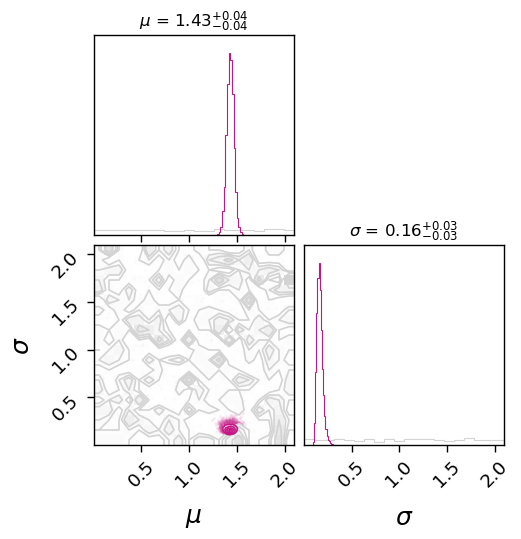

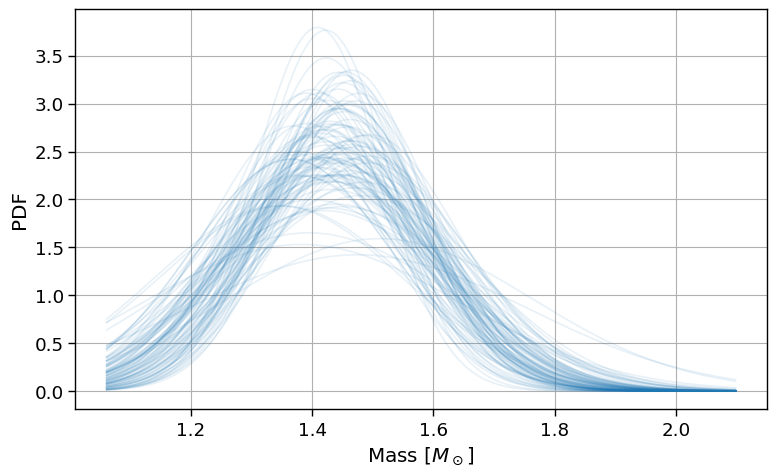

Single Gaussian (Uniform Prior):
logl gaussian_uniform:  1.4121889





sample: 100%|██████████| 2000/2000 [00:00<00:00, 2119.83it/s, 7 steps of size 6.77e-01. acc. prob=0.89]


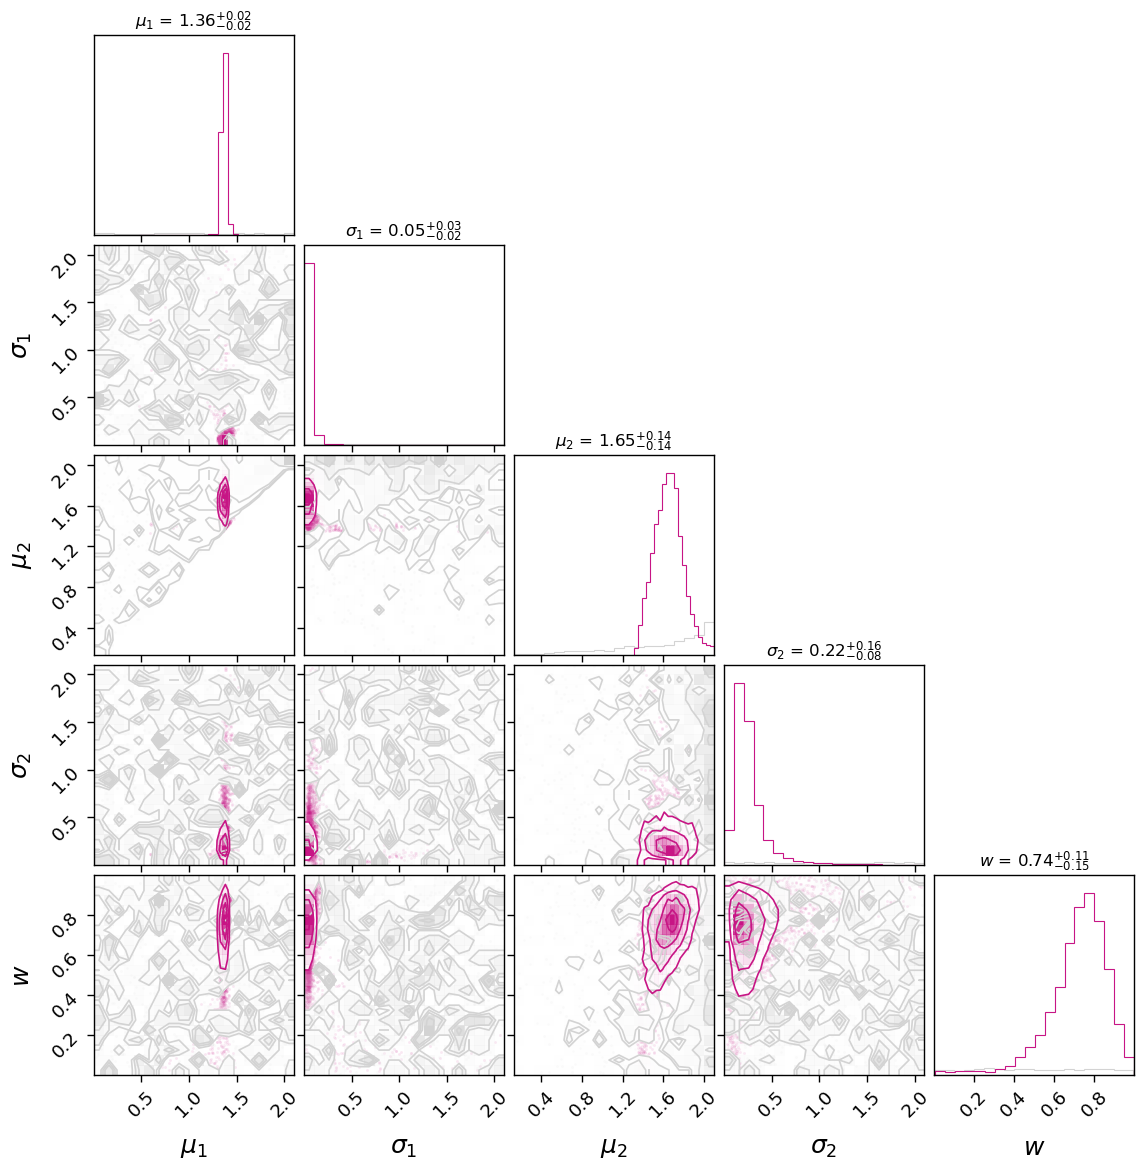

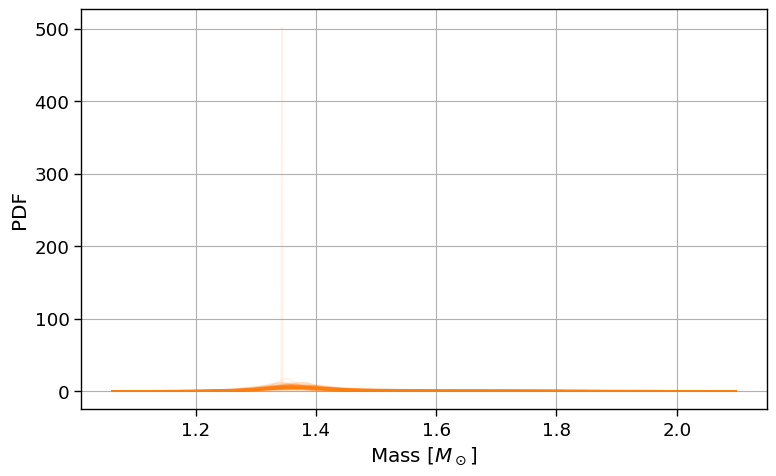

Double Gaussian (Uniform Prior):
logl double_uniform:  17.207262






In [72]:
rng = random.PRNGKey(0)

# Fit single Gaussian - uniform prior
rng, rng_infer_single = random.split(rng)
mcmc_gaussian_uniform = run_inference(gaussian_uniform, gaia_data, gaia_data_err, rng_infer_single)
samples_gaussian_uniform= az.from_numpyro(mcmc_gaussian_uniform)

rng, rng_prior_single = random.split(rng)
prior_sampler = MCMC(NUTS(gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(rng_prior_single,gaia_data, gaia_data_err, prior=True)   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='lightgrey',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_gaussian_uniform,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()

plot_mass_distributions(mcmc_gaussian_uniform, "single", gaia_data, label="Gaia")

print("Single Gaussian (Uniform Prior):")
logl_gaussian_uniform = log_likelihood(gaussian_uniform, mcmc_gaussian_uniform.get_samples(), data=gaia_data, err=gaia_data_err)['obs']
print("logl gaussian_uniform: ", np.max(logl_gaussian_uniform))
print()
print()
print()


# Fit two-component Gaussian - Uniform prior
rng, rng_infer_double = random.split(rng)
mcmc_double_uniform = run_inference(double_gaussian_uniform, gaia_data, gaia_data_err, rng_infer_double)
samples_double_uniform = az.from_numpyro(mcmc_double_uniform)

rng, rng_prior_double = random.split(rng)
prior_sampler = MCMC(NUTS(double_gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(rng_prior_double, gaia_data, gaia_data_err, prior=True)   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='lightgrey',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_double_uniform,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='mediumvioletred',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()

plot_mass_distributions(mcmc_double_uniform, "double", gaia_data, label="Data")

print("Double Gaussian (Uniform Prior):")
logl_double_uniform = log_likelihood(double_gaussian_uniform, mcmc_double_uniform.get_samples(), data=gaia_data, err=gaia_data_err)['obs']
print("logl double_uniform: ", np.max(logl_double_uniform))   
print()
print()
print()
print()


In [73]:
# save the fits for comparison with the other populations later
gaia_corner_samples = samples_double_uniform

gaiafit = mcmc_double_uniform
gaiafit_samples = gaiafit.get_samples()

gaiafit_single = mcmc_gaussian_uniform
gaiafit_single_samples = gaiafit_single.get_samples()

array([[<Axes: title={'center': 'log_L'}>,
        <Axes: title={'center': 'log_L'}>],
       [<Axes: title={'center': 'mu1'}>, <Axes: title={'center': 'mu1'}>],
       [<Axes: title={'center': 'mu2'}>, <Axes: title={'center': 'mu2'}>],
       [<Axes: title={'center': 'sigma1'}>,
        <Axes: title={'center': 'sigma1'}>],
       [<Axes: title={'center': 'sigma2'}>,
        <Axes: title={'center': 'sigma2'}>],
       [<Axes: title={'center': 'weight'}>,
        <Axes: title={'center': 'weight'}>]], dtype=object)

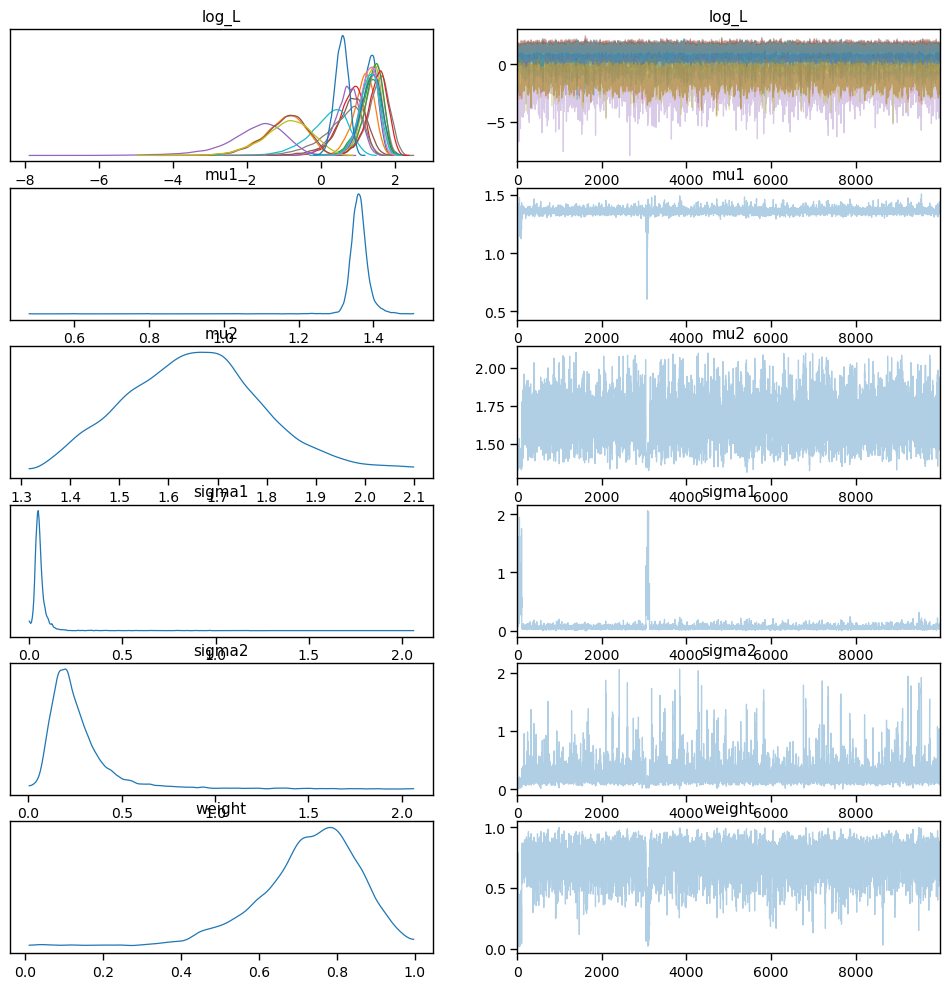

In [74]:
az.plot_trace(gaiafit)

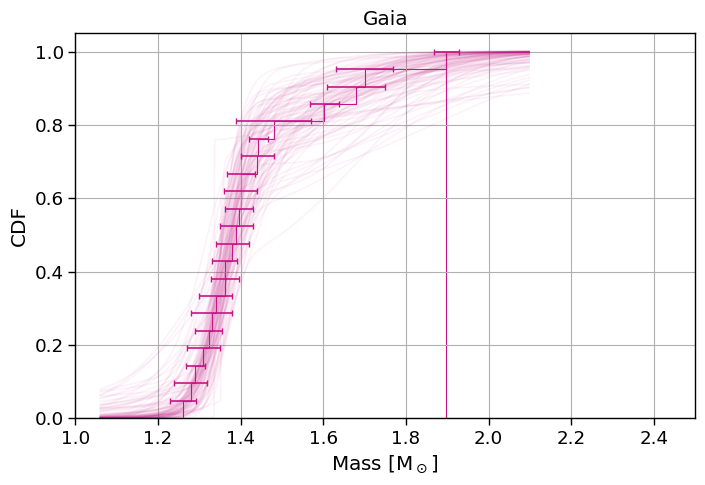

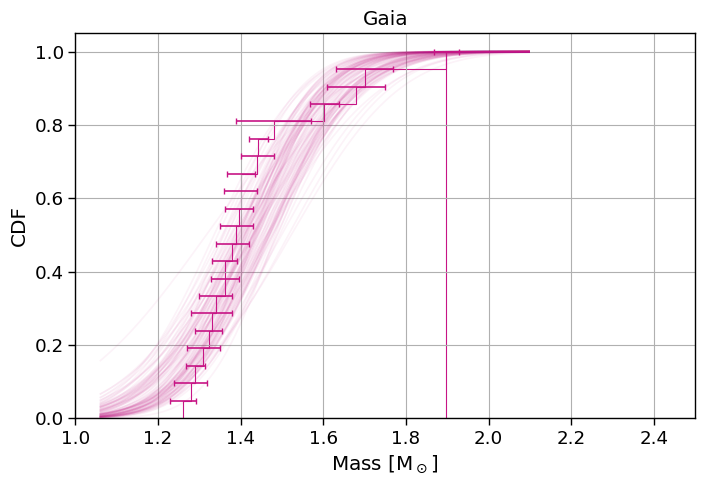

In [75]:
### Plot CDF of fit with data

gaia_masses, gaia_uerrors, gaia_lerrors, gaia_bins = plot_cdf(gaia_data,gaia_data_err,gaia_data_err)

plt.figure(figsize=(8,5))

x = np.linspace(min(gaia_data) - 0.2, max(gaia_data) + 0.2, 1000)

for i in np.random.choice(len(gaiafit_samples['mu1']), 100, replace=False):
    y = gaiafit_samples['weight'][i] * scipy.stats.norm.cdf(
        x, loc=gaiafit_samples['mu1'][i], scale=gaiafit_samples['sigma1'][i]) + (1 - gaiafit_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=gaiafit_samples['mu2'][i], scale=gaiafit_samples['sigma2'][i])
    plt.plot(x, y, alpha=0.05, color='mediumvioletred', label='Gaia')

plt.stairs(np.array(range(len(gaia_masses)+1))/len(gaia_masses),gaia_bins, alpha =1 ,color='mediumvioletred')
plt.errorbar(gaia_masses, np.array(range(len(gaia_masses)+1))[1:]/len(gaia_masses), xerr = (gaia_uerrors, gaia_lerrors), color='mediumvioletred', ls = "None", capsize = 2)
plt.ylabel("CDF")
plt.xlabel("Mass [M$_\odot$]")
plt.title("Gaia")
plt.xlim(1.0, 2.5)
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
for i in np.random.choice(len(gaiafit_single_samples['mu']), 100, replace=False):
    y = scipy.stats.norm.cdf(x, loc=gaiafit_single_samples['mu'][i], scale=gaiafit_single_samples['sigma'][i])
    plt.plot(x, y, alpha=0.05, color='mediumvioletred', label='Gaia')

plt.stairs(np.array(range(len(gaia_masses)+1))/len(gaia_masses),gaia_bins, alpha =1 ,color='mediumvioletred')
plt.errorbar(gaia_masses, np.array(range(len(gaia_masses)+1))[1:]/len(gaia_masses), xerr = (gaia_uerrors, gaia_lerrors), color='mediumvioletred', ls = "None", capsize = 2)

plt.ylabel("CDF")
plt.xlabel("Mass [M$_\odot$]")
plt.title("Gaia")
plt.xlim(1.0, 2.5)
plt.grid()
plt.show()

In [76]:
log_likelihood_dict = numpyro.infer.log_likelihood(gaussian_uniform, gaiafit_single_samples, data=gaia_data, err=gaia_data_err) # log likelihoods for each data point in each sample
logL_numpyro_gaussian = max(jnp.sum(log_likelihood_dict['obs'], axis=1))  # summing the likelihoods across all data points for each sample
print("The max logL for the single Gaussian model is:", (logL_numpyro_gaussian))
print()

log_likelihood_dict = numpyro.infer.log_likelihood(double_gaussian_uniform, gaiafit_samples, data=gaia_data, err=gaia_data_err)
logL_numpyro_double_gaussian = max(jnp.sum(gaiafit_samples['log_L'], axis=1))
print("The max logL for the double Gaussian model is:", logL_numpyro_double_gaussian)
print()

print(np.exp(logL_numpyro_double_gaussian - logL_numpyro_gaussian))

The max logL for the single Gaussian model is: 9.117367

The max logL for the double Gaussian model is: 17.207262

3261.346


ratio of posterior support: 22.23531933387634

savage dickey ratio for w=0: 43.013576275992015
savage dickey ratio for w=1: 7.928975447175611
savage dickey ratio for w=0 and 1: 13.389733283912117
savage dickey ratio at max weight: 0.3010915445570498


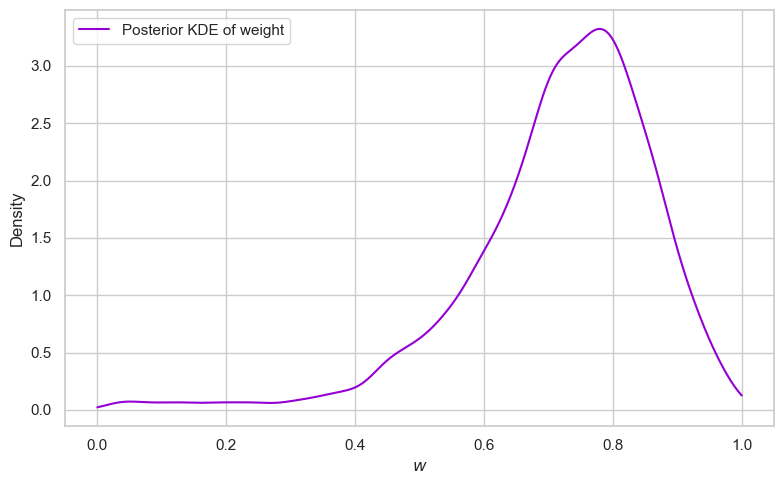

In [183]:
### compare the posterior of the weight parameter - single vs double Gaussian

from scipy.stats import gaussian_kde

weights = gaiafit_samples['weight']

# KDE of the posterior
kde = gaussian_kde(weights)


posterior_at_0 = kde.evaluate(0)[0]
posterior_at_1 = kde.evaluate(1)[0]
maxposterior = kde.evaluate(weights).max()

print("ratio of posterior support:",maxposterior/ (posterior_at_0 + posterior_at_1))  
print()
print("savage dickey ratio for w=0:", 1 / (posterior_at_0))
print("savage dickey ratio for w=1:", 1 / (posterior_at_1))
print("savage dickey ratio for w=0 and 1:", 2 / (posterior_at_1+ posterior_at_0))
print("savage dickey ratio at max weight:", 1/maxposterior)

# Plot
x = np.linspace(0, 1, 500)
y = kde.evaluate(x)
plt.figure(figsize=(8, 5))
plt.plot(x, y, label='Posterior KDE of weight', color='darkviolet')
plt.xlabel("$w$")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Recycled NS

sample: 100%|██████████| 2000/2000 [00:00<00:00, 2759.10it/s, 3 steps of size 7.62e-01. acc. prob=0.92]


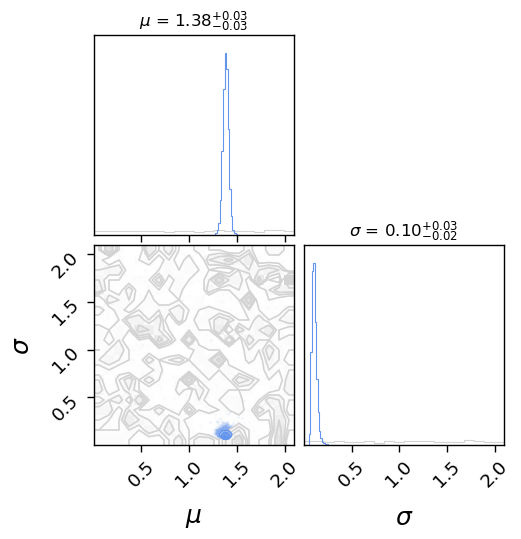

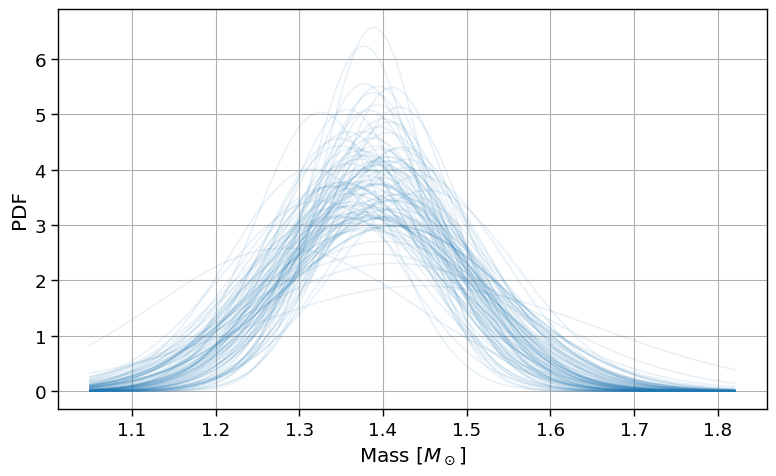

Single Gaussian (Uniform Prior):
logl gaussian_uniform:  1.9797146





sample: 100%|██████████| 2000/2000 [00:00<00:00, 2056.28it/s, 7 steps of size 6.77e-01. acc. prob=0.89]


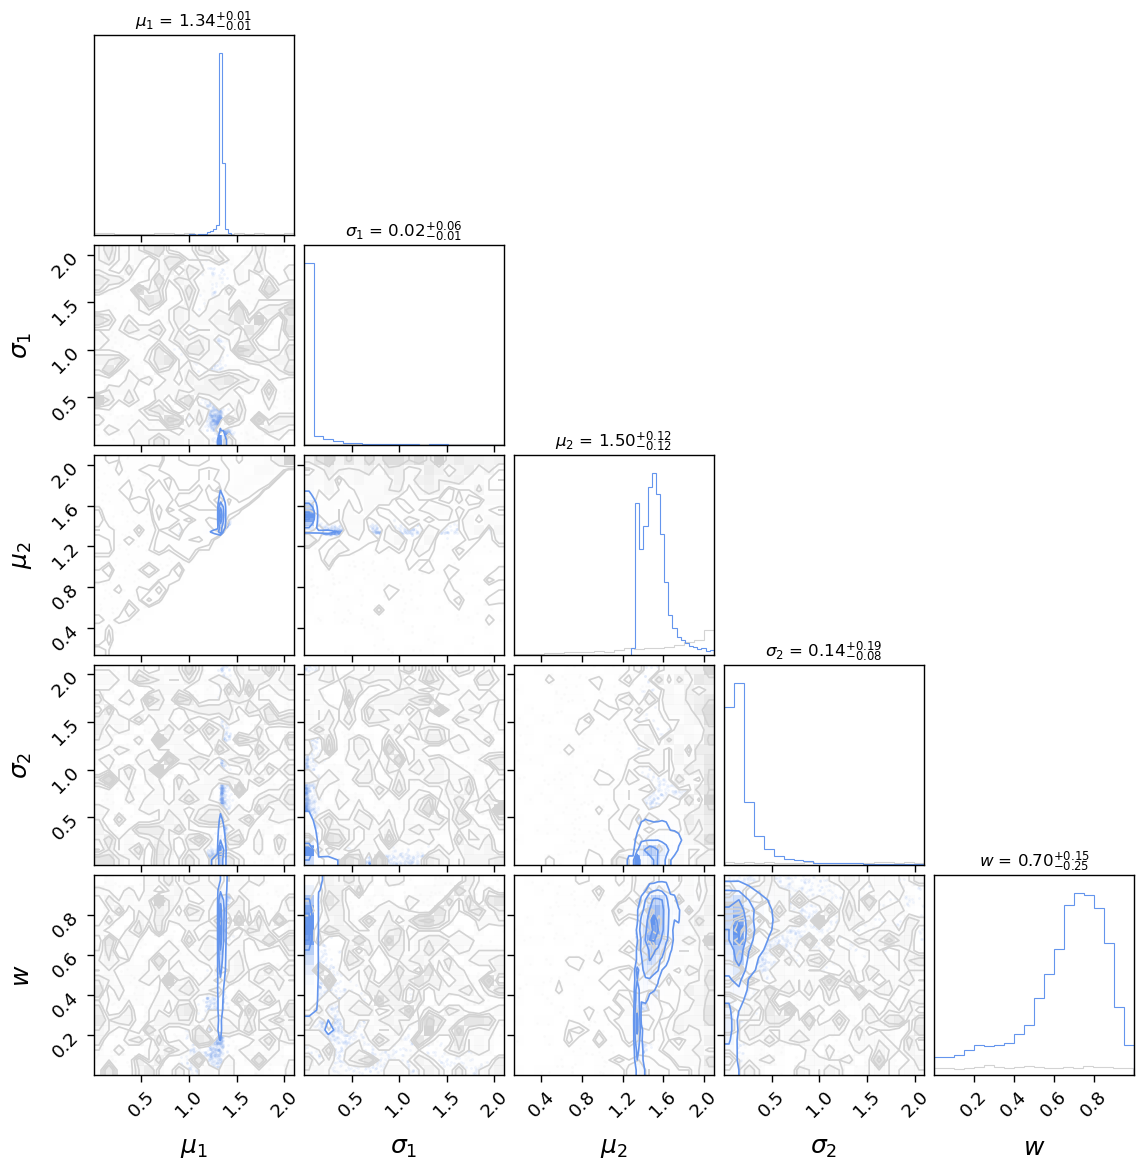

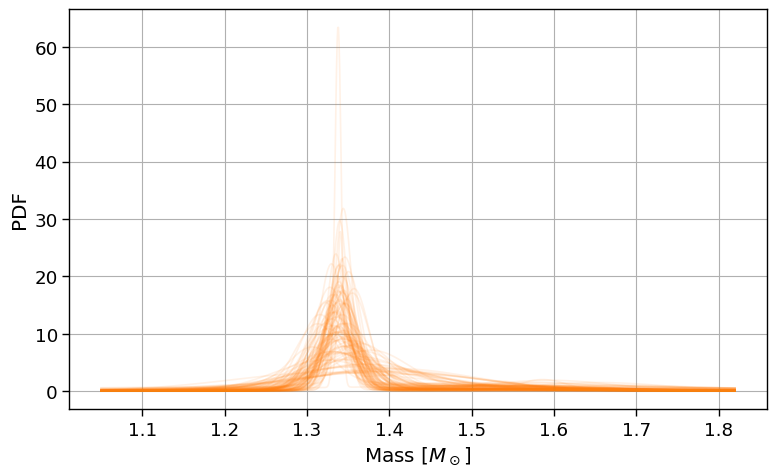

Double Gaussian (Uniform Prior):
logl double_uniform:  21.059195





In [78]:
rng = random.PRNGKey(0)

# Fit single Gaussian - uniform prior
rng, rng_infer_single = random.split(rng)
mcmc_gaussian_uniform = run_inference(gaussian_uniform, DNS_data, DNS_data_err, rng_infer_single)
samples_gaussian_uniform= az.from_numpyro(mcmc_gaussian_uniform)

rng, rng_prior_single = random.split(rng)
prior_sampler = MCMC(NUTS(gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(rng_prior_single,DNS_data, DNS_data_err, prior=True)   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='lightgrey',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_gaussian_uniform,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='cornflowerblue',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

plt.show()

plot_mass_distributions(mcmc_gaussian_uniform, "single", DNS_data, label="Recycled NS")

print("Single Gaussian (Uniform Prior):")
logl_gaussian_uniform = log_likelihood(gaussian_uniform, mcmc_gaussian_uniform.get_samples(), data=DNS_data, err=DNS_data_err)['obs']
print("logl gaussian_uniform: ", np.max(logl_gaussian_uniform))
print()
print()
print()

# Fit two-component Gaussian - Uniform prior
rng, rng_infer_double = random.split(rng)
mcmc_double_uniform = run_inference(double_gaussian_uniform, DNS_data, DNS_data_err, rng_infer_double)
samples_double_uniform = az.from_numpyro(mcmc_double_uniform)

rng
prior_sampler = MCMC(NUTS(double_gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(rng_prior_double, DNS_data, DNS_data_err, prior=True)   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='lightgrey',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_double_uniform,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='cornflowerblue',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()

plot_mass_distributions(mcmc_double_uniform, "double", DNS_data, label="Recycled NS")

print("Double Gaussian (Uniform Prior):")
logl_double_uniform = log_likelihood(double_gaussian_uniform, mcmc_double_uniform.get_samples(), data=DNS_data, err=DNS_data_err)['obs']
print("logl double_uniform: ", np.max(logl_double_uniform))   
print()
print()
print()

In [79]:
# Save the fits for comparison with the other populations later
DNS_corner_samples = samples_double_uniform

recycledDNSfit = mcmc_double_uniform
recycledDNSfit_samples = recycledDNSfit.get_samples()

recycledDNSfit_single = mcmc_gaussian_uniform
recycledDNSfit_single_samples = recycledDNSfit_single.get_samples()

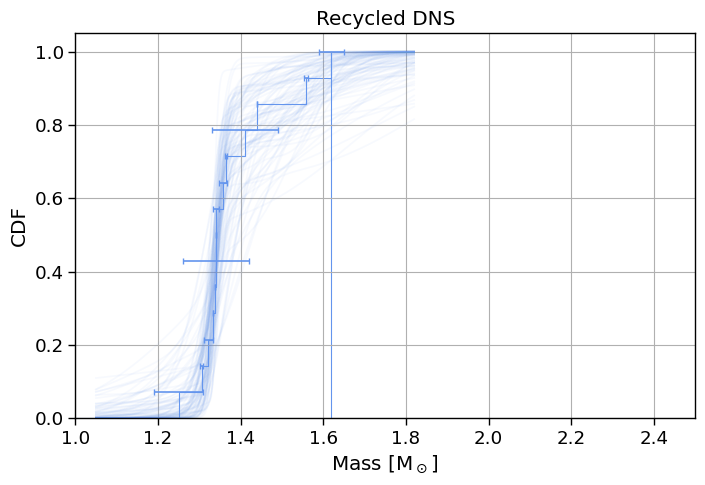

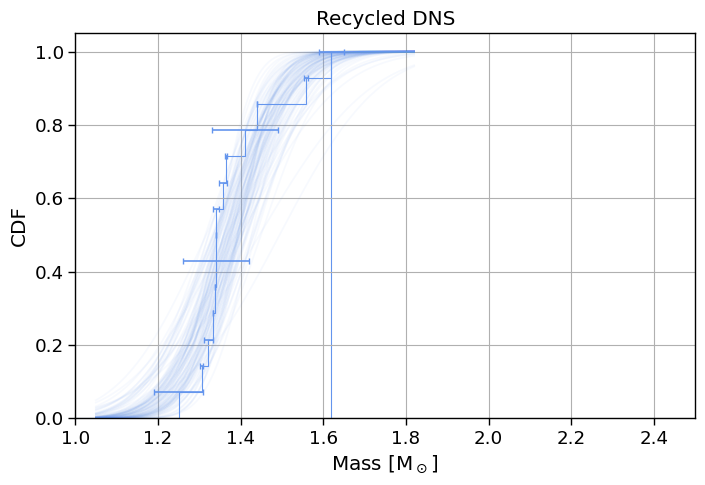

In [80]:
# Plot CDF of fit with data

DNS_masses, DNS_uerrors, DNS_lerrors, DNS_bins =plot_cdf(DNS_data,DNS_data_err,DNS_data_err)

x = np.linspace(min(DNS_data) - 0.2, max(DNS_data) + 0.2, 1000)

fig = plt.figure(figsize=(8,5))
for i in np.random.choice(len(recycledDNSfit_samples['mu1']), 100, replace=False):
    y = recycledDNSfit_samples['weight'][i] * scipy.stats.norm.cdf(
        x, loc=recycledDNSfit_samples['mu1'][i], scale=recycledDNSfit_samples['sigma1'][i]  
    ) + (1 - recycledDNSfit_samples['weight'][i]) * scipy.stats.norm.cdf(
        x, loc=recycledDNSfit_samples['mu2'][i], scale=recycledDNSfit_samples['sigma2'][i]  
    )
    plt.plot(x, y, alpha=0.05, color='cornflowerblue', label='Recycled DNS')

plt.stairs(np.array(range(len(DNS_masses)+1))/len(DNS_masses),DNS_bins, alpha =1 ,color='cornflowerblue')
plt.errorbar(DNS_masses, np.array(range(len(DNS_masses)+1))[1:]/len(DNS_masses), xerr = (DNS_uerrors, DNS_lerrors), color='cornflowerblue', ls = "None", capsize = 2)
plt.ylabel("CDF")
plt.xlabel("Mass [M$_\odot$]")
plt.title("Recycled DNS")
plt.xlim(1.0, 2.5)
plt.grid()
plt.show()

fig = plt.figure(figsize=(8,5))
for i in np.random.choice(len(recycledDNSfit_single_samples['mu']), 100, replace=False):
    y =  scipy.stats.norm.cdf(x, loc=recycledDNSfit_single_samples['mu'][i], scale=recycledDNSfit_single_samples['sigma'][i])
    plt.plot(x, y, alpha=0.05, color='cornflowerblue', label='Recycled DNS')

plt.stairs(np.array(range(len(DNS_masses)+1))/len(DNS_masses),DNS_bins, alpha =1 ,color='cornflowerblue')
plt.errorbar(DNS_masses, np.array(range(len(DNS_masses)+1))[1:]/len(DNS_masses), xerr = (DNS_uerrors, DNS_lerrors), color='cornflowerblue', ls = "None", capsize = 2)
plt.ylabel("CDF")
plt.xlabel("Mass [M$_\odot$]")
plt.title("Recycled DNS")
plt.xlim(1.0, 2.5)
plt.grid()
plt.show()




In [81]:
log_likelihood_dict = numpyro.infer.log_likelihood(gaussian_uniform, recycledDNSfit_single_samples, data=DNS_data, err=DNS_data_err)
logL_numpyro = jnp.sum(log_likelihood_dict['obs'], axis=1)  # Now shape (1000,)
print(logL_numpyro)
print(max(logL_numpyro))
print()


log_likelihood_dict = numpyro.infer.log_likelihood(double_gaussian_uniform, recycledDNSfit_samples, data=DNS_data, err=DNS_data_err)
print(log_likelihood_dict)
print()
print(jnp.sum(gaiafit_samples['log_L'], axis=1))
print(max(jnp.sum(gaiafit_samples['log_L'], axis=1)))
print()

[11.076809 12.044982 11.988388 ... 11.498499 11.411436 12.130802]
12.797602

{'obs': Array([15.910537, 15.777569, 16.821331, ..., 19.257555, 18.414515,
       19.127625], dtype=float32)}

[ 8.682577   9.267101   9.3419895 ... 15.263025  14.537574  15.151625 ]
17.207262



ratio of posterior support: 7.377122689651492

savage dickey ratio for w=0: 8.953002325821572
savage dickey ratio for w=1: 4.743781045900706
savage dickey ratio for w=0 and 1: 3.1008070715947125
savage dickey ratio at max weight: 0.42032743686701507


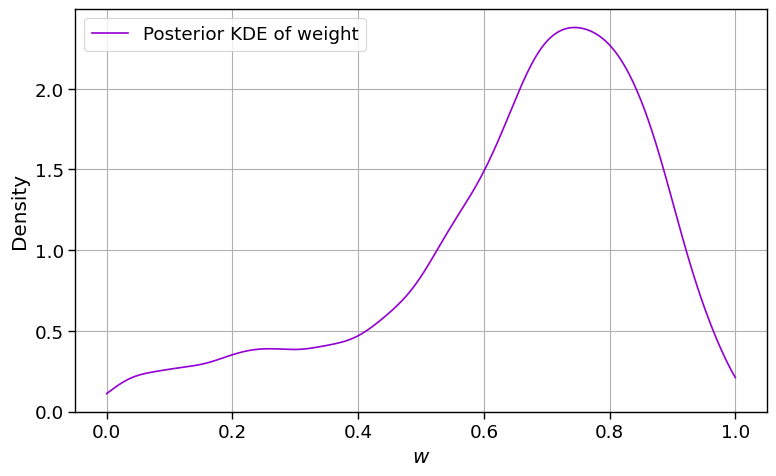

In [82]:
weights = recycledDNSfit_samples['weight']

# KDE of the posterior
kde = gaussian_kde(weights)


posterior_at_0 = kde.evaluate(0)[0]
posterior_at_1 = kde.evaluate(1)[0]
maxposterior = kde.evaluate(weights).max()

print("ratio of posterior support:",maxposterior/ (posterior_at_0 + posterior_at_1))  
print()
print("savage dickey ratio for w=0:", 1 / (posterior_at_0))
print("savage dickey ratio for w=1:", 1 / (posterior_at_1))
print("savage dickey ratio for w=0 and 1:", 1 / (posterior_at_1+ posterior_at_0))
print("savage dickey ratio at max weight:", 1/maxposterior)

# Plot
x = np.linspace(0, 1, 500)
y = kde.evaluate(x)
plt.figure(figsize=(8, 5))
plt.plot(x, y, label='Posterior KDE of weight', color='darkviolet')
plt.xlabel("$w$")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Slow Neutron Stars

sample: 100%|██████████| 2000/2000 [00:00<00:00, 2568.65it/s, 3 steps of size 7.62e-01. acc. prob=0.92]


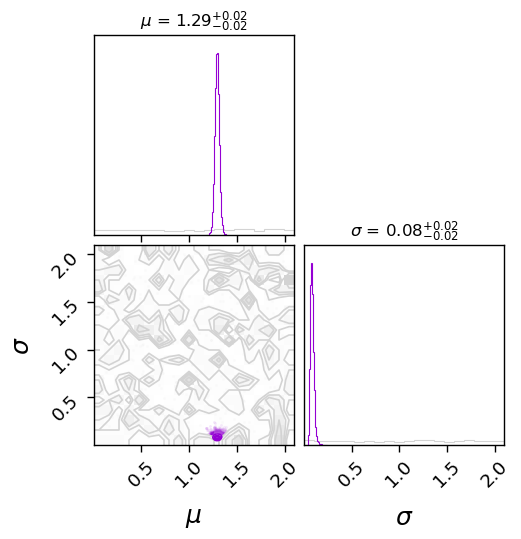

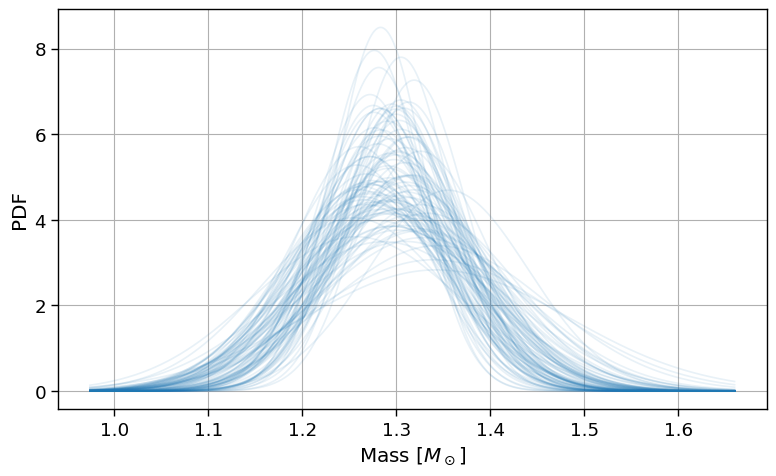

Single Gaussian (Uniform Prior):





sample: 100%|██████████| 2000/2000 [00:00<00:00, 2062.16it/s, 7 steps of size 6.77e-01. acc. prob=0.89]


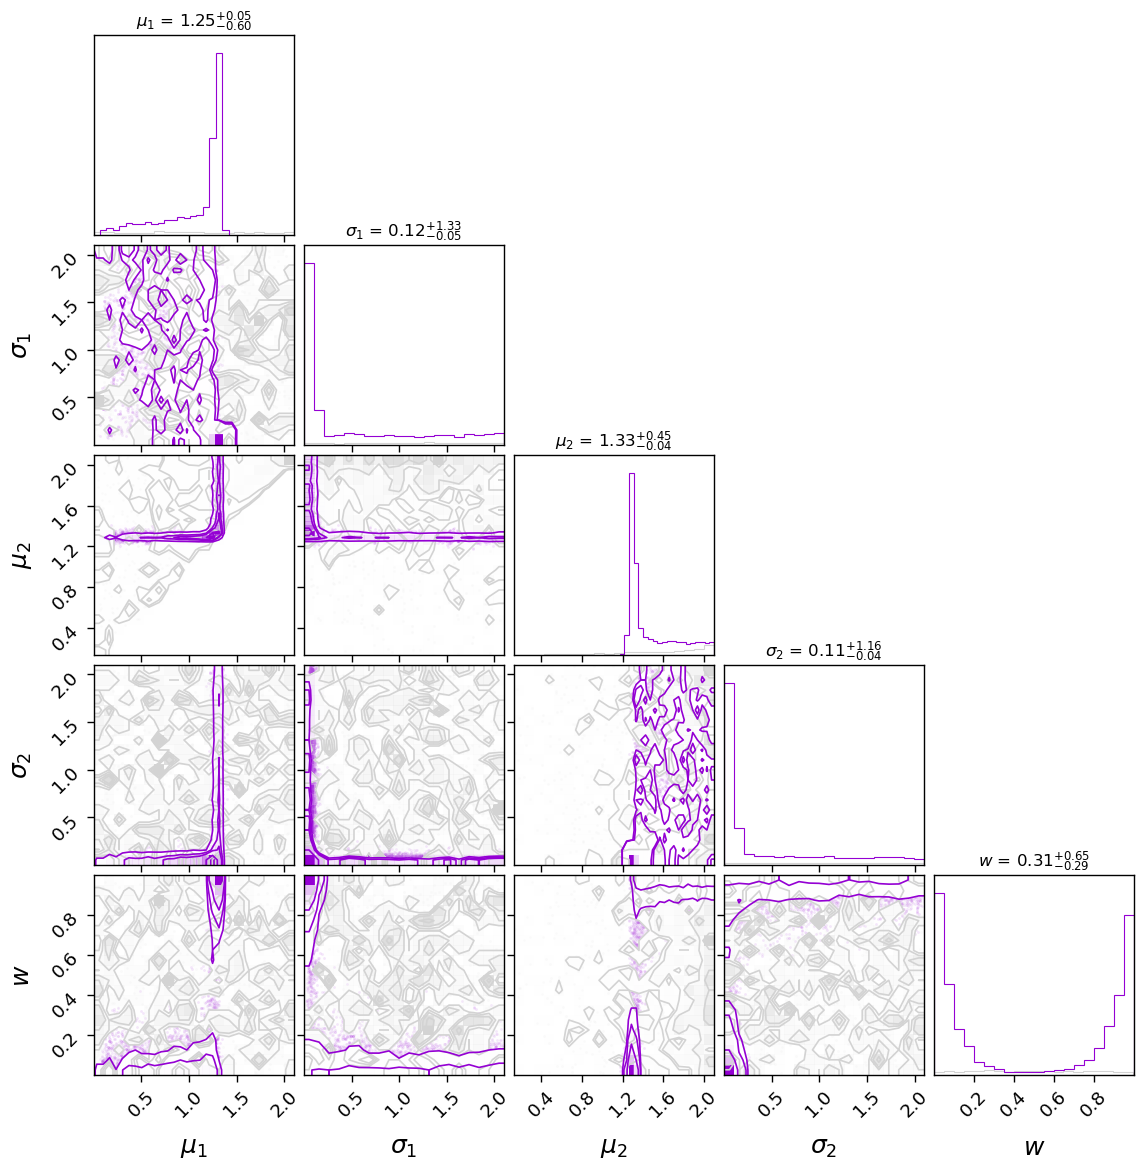

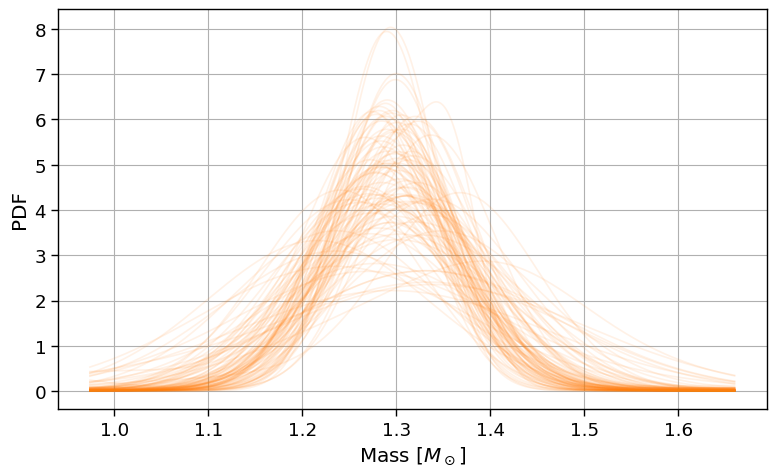

Double Gaussian (Uniform Prior):






In [89]:
slow_data = DNS['m2'].dropna().to_numpy()
slow_data_err = DNS[['m2_uerr', 'm2_lerr']].max(axis=1).dropna().to_numpy()

rng = random.PRNGKey(0)

# Fit single Gaussian - uniform prior
rng, rng_infer_single = random.split(rng)
mcmc_gaussian_uniform = run_inference(gaussian_uniform, slow_data, slow_data_err, rng_infer_single)
samples_gaussian_uniform= az.from_numpyro(mcmc_gaussian_uniform)

rng, rng_prior_single = random.split(rng)
prior_sampler_gaussian = MCMC(NUTS(gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler_gaussian.run(rng_prior_single, slow_data, slow_data_err, prior=True)   
prior_samples_gaussian = prior_sampler_gaussian.get_samples()

fig = corner.corner(
    prior_samples_gaussian,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='lightgrey',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_gaussian_uniform,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='darkviolet',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

plt.show()

#corner_plot(mcmc_gaussian_uniform, "single", "Posterior: Single Gaussian - Uniform Prior")
plot_mass_distributions(mcmc_gaussian_uniform, "single", slow_data, label="Slow NS")

print("Single Gaussian (Uniform Prior):")
#logl_gaussian_uniform = log_likelihood(gaussian_uniform, mcmc_gaussian_uniform.get_samples(), data=slow_data, err=slow_data_err)['obs']
#print("logl gaussian_uniform: ", np.max(logl_gaussian_uniform))
print()
print()
print()


# Fit two-component Gaussian - Uniform prior
rng, rng_infer_double = random.split(rng)
mcmc_double_uniform = run_inference(double_gaussian_uniform, slow_data, slow_data_err, rng_infer_double)
samples_double_uniform = az.from_numpyro(mcmc_double_uniform)

rng, rng_prior_double = random.split(rng)
prior_sampler_double = MCMC(NUTS(double_gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler_double.run(rng_prior_double, slow_data, slow_data_err, prior=True)   
prior_samples_double = prior_sampler_double.get_samples()

fig = corner.corner(
    prior_samples_double,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='lightgrey',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_double_uniform,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='darkviolet',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()

#corner_plot(mcmc_double_uniform, "double", "Posterior: Two-Gaussian Mixture - Uniform Prior")
plot_mass_distributions(mcmc_double_uniform, "double", slow_data, label="Slow NS")

print("Double Gaussian (Uniform Prior):")
#logl_double_uniform = log_likelihood(double_gaussian_uniform, mcmc_double_uniform.get_samples(), data=slow_data, err=slow_data_err)['obs']
#print("logl double_uniform: ", np.max(logl_double_uniform))   
print()
print()
print()
print()

100%|██████████| 5000/5000 [00:01<00:00, 3802.48it/s]


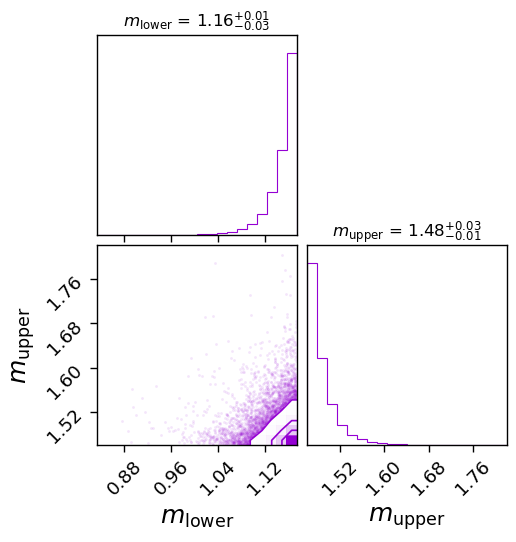

In [84]:
# Fit uniform bounds using emcee - since NUTS isn't good for sharp bounds such as in a uniform distribution
import emcee

# Define the log-likelihood function
def log_likelihood(theta, data):
    m_lower, m_upper = theta
    if m_lower >= m_upper or m_lower < 0.8 or m_upper > 2:
        return -np.inf  # Return -inf for invalid parameter values
    if np.any(data < m_lower) or np.any(data > m_upper):
        return -np.inf  # Return -inf if data falls outside the bounds
    return len(data) * np.log(1 / (m_upper - m_lower))  # Uniform log-likelihood

# Define the log-prior function
def log_prior(theta):
    m_lower, m_upper = theta
    if 0.8 <= m_lower < m_upper <= 2:
        return 0.0  # Uniform prior within the bounds
    return -np.inf  # Return -inf for invalid parameter values

# Define the log-posterior function
def log_posterior(theta, data):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, data)

# Set up the MCMC sampler
n_walkers = 32
n_dim = 2
n_steps = 5000

# Initialize the walkers in a small region around valid parameter values
initial_positions = np.random.uniform(low=[0.8, 1.9], high=[1.0, 2.0], size=(n_walkers, n_dim))

# Initialize the sampler
sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_posterior, args=(slow_data,))

# Run the MCMC chain
sampler.run_mcmc(initial_positions, n_steps, progress=True)

# Extract the samples
samples_uniform = sampler.get_chain(discard=100, thin=10, flat=True)

corner.corner(
    samples_uniform,  # Posterior samples
    # var_names=["low", "high"],
    labels=[r"$m_{\mathrm{lower}}$", r"$m_{\mathrm{upper}}$"],
    color="darkviolet",
    #fig=fig,  # Overlay on the same figure
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 18},
)

plt.show()

In [85]:
# save the fits for comparison with the other populations later
slowDNSfit_samples = samples_uniform#slowDNSfit.get_samples()

slow_single = mcmc_gaussian_uniform
slow_single_samples = slow_single.get_samples()

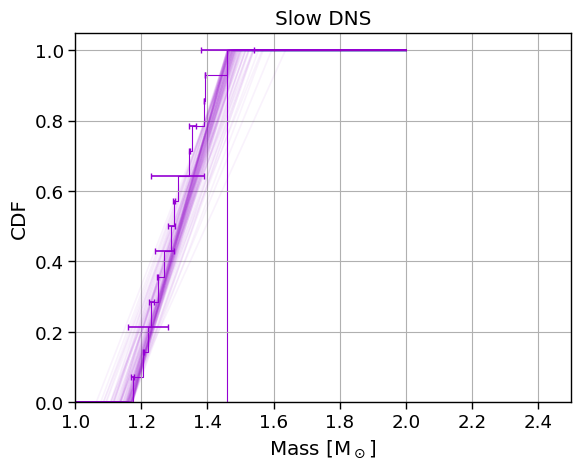

In [86]:
#Plot CDF of fit with data

slow_masses, slow_uerrors, slow_lerrors, slow_bins =plot_cdf(slow_data,slow_data_err,slow_data_err)

x = np.linspace(1,2, 1000)

low = slowDNSfit_samples[:, 0]    
high = slowDNSfit_samples[:, 1]

for i in np.random.choice(len(low), 100, replace=False):
    y = scipy.stats.uniform.cdf(x, loc=low[i], scale=high[i] - low[i])
    
    plt.plot(x, y, alpha=0.05, color='darkviolet', label='Slow DNS')

plt.stairs(np.array(range(len(slow_masses)+1))/len(slow_masses),slow_bins, alpha =1 ,color='darkviolet')
plt.errorbar(slow_masses, np.array(range(len(slow_masses)+1))[1:]/len(slow_masses), xerr = (slow_uerrors, slow_lerrors), color='darkviolet', ls = "None", capsize = 2)
plt.ylabel("CDF")
plt.xlabel("Mass [M$_\odot$]")
plt.title("Slow DNS")
plt.xlim(1.0, 2.5)
plt.grid()
plt.show()

In [87]:
### Model comparison

from jax.scipy.stats import norm

def compute_log_likelihoods(mu_grid, sigma_grid, data, err):
    N = data.shape[0]
    num_samples = mu_grid.shape[0]

    # Broadcast mu and sigma to (1000, N)
    mu_broadcast = mu_grid[:, None]  # shape (1000, 1)
    sigma_broadcast = sigma_grid[:, None]  # shape (1000, 1)
    
    # Combine sigma and err
    total_sigma = jnp.sqrt(sigma_broadcast**2 + err[None, :]**2)  # (1000, N)

    # Compute log probability of each data point
    log_probs = norm.logpdf(data[None, :], loc=mu_broadcast, scale=total_sigma)  # (1000, N)

    # Sum over data points
    total_log_likelihoods = jnp.sum(log_probs, axis=1)  # shape (1000,)

    return total_log_likelihoods
slow_single_logL = compute_log_likelihoods(slow_single_samples['mu'], slow_single_samples['sigma'], slow_data, slow_data_err)
print(slow_single_logL)

log_likelihood_dict = numpyro.infer.log_likelihood(gaussian_uniform, slow_single_samples, data=slow_data, err=slow_data_err)
logL_numpyro = jnp.sum(log_likelihood_dict['obs'], axis=1)  # Now shape (1000,)
print(logL_numpyro)
print(max(logL_numpyro))
print()

log_likelihoods = np.array([
    log_likelihood(theta, slow_data)
    for theta in samples_uniform
])

# Get the sample with the highest log likelihood
max_index = np.argmax(log_likelihoods)
best_theta = samples_uniform[max_index]
max_log_likelihood = log_likelihoods[max_index]

print(log_likelihoods)
print(max(log_likelihoods))


[15.457728 15.106626 15.488687 ... 15.59133  15.59133  15.298838]
[15.457728  15.106626  15.4886875 ... 15.59133   15.59133   15.298838 ]
16.136503

[16.28412155 14.37711088 12.8143098  ... 11.39109291 16.4081911
 16.80804017]
17.515465437707913


ratio of posterior support: 0.6467349123597076

savage dickey ratio for w=0: 0.5441680940332833
savage dickey ratio for w=1: 0.613560952298518
savage dickey ratio for w=0 and 1: 0.2883924308916767
savage dickey ratio at max weight: 0.44592061659302484


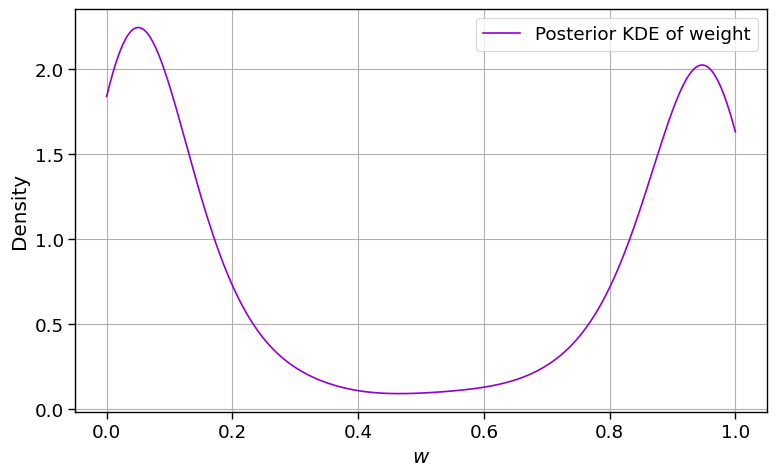

In [ ]:
# this is flawed because it uses the maximum posterior but this is near 0 and 1, so should make a metric that looks at all points away from 0 and 1 or something
weights = mcmc_double_uniform.get_samples()['weight']

# KDE of the posterior
kde = gaussian_kde(weights)


posterior_at_0 = kde.evaluate(0)[0]
posterior_at_1 = kde.evaluate(1)[0]
maxposterior = kde.evaluate(weights).max()

print("ratio of posterior support:",maxposterior/ (posterior_at_0 + posterior_at_1))  
print()
print("savage dickey ratio for w=0:", 1 / (posterior_at_0))
print("savage dickey ratio for w=1:", 1 / (posterior_at_1))
print("savage dickey ratio for w=0 and 1:", 1 / (posterior_at_1+ posterior_at_0))
print("savage dickey ratio at max weight:", 1/maxposterior)

# Plot
x = np.linspace(0, 1, 500)
y = kde.evaluate(x)
plt.figure(figsize=(8, 5))
plt.plot(x, y, label='Posterior KDE of weight', color='darkviolet')
plt.xlabel("$w$")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# NS-WD

sample: 100%|██████████| 2000/2000 [00:00<00:00, 2795.49it/s, 3 steps of size 7.62e-01. acc. prob=0.92]


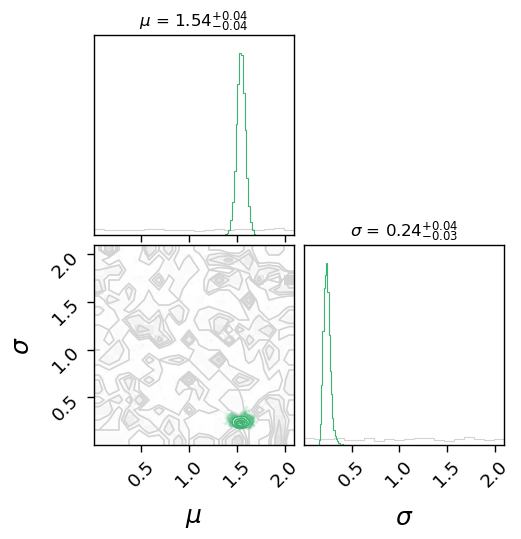

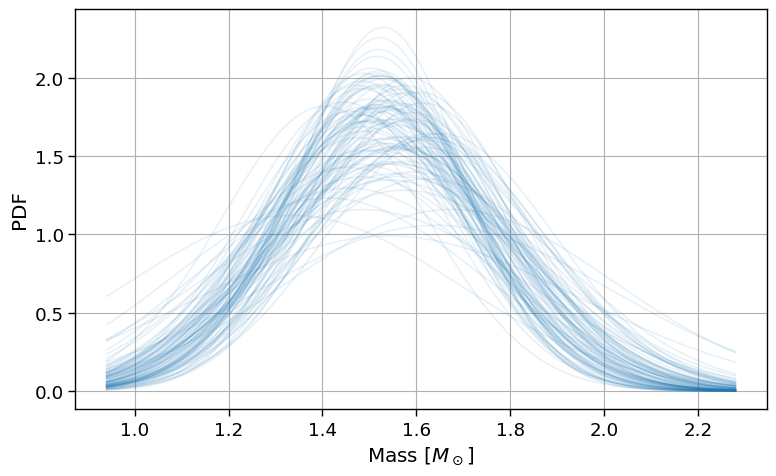

Single Gaussian (Uniform Prior):





sample: 100%|██████████| 2000/2000 [00:01<00:00, 1919.42it/s, 7 steps of size 6.77e-01. acc. prob=0.89]


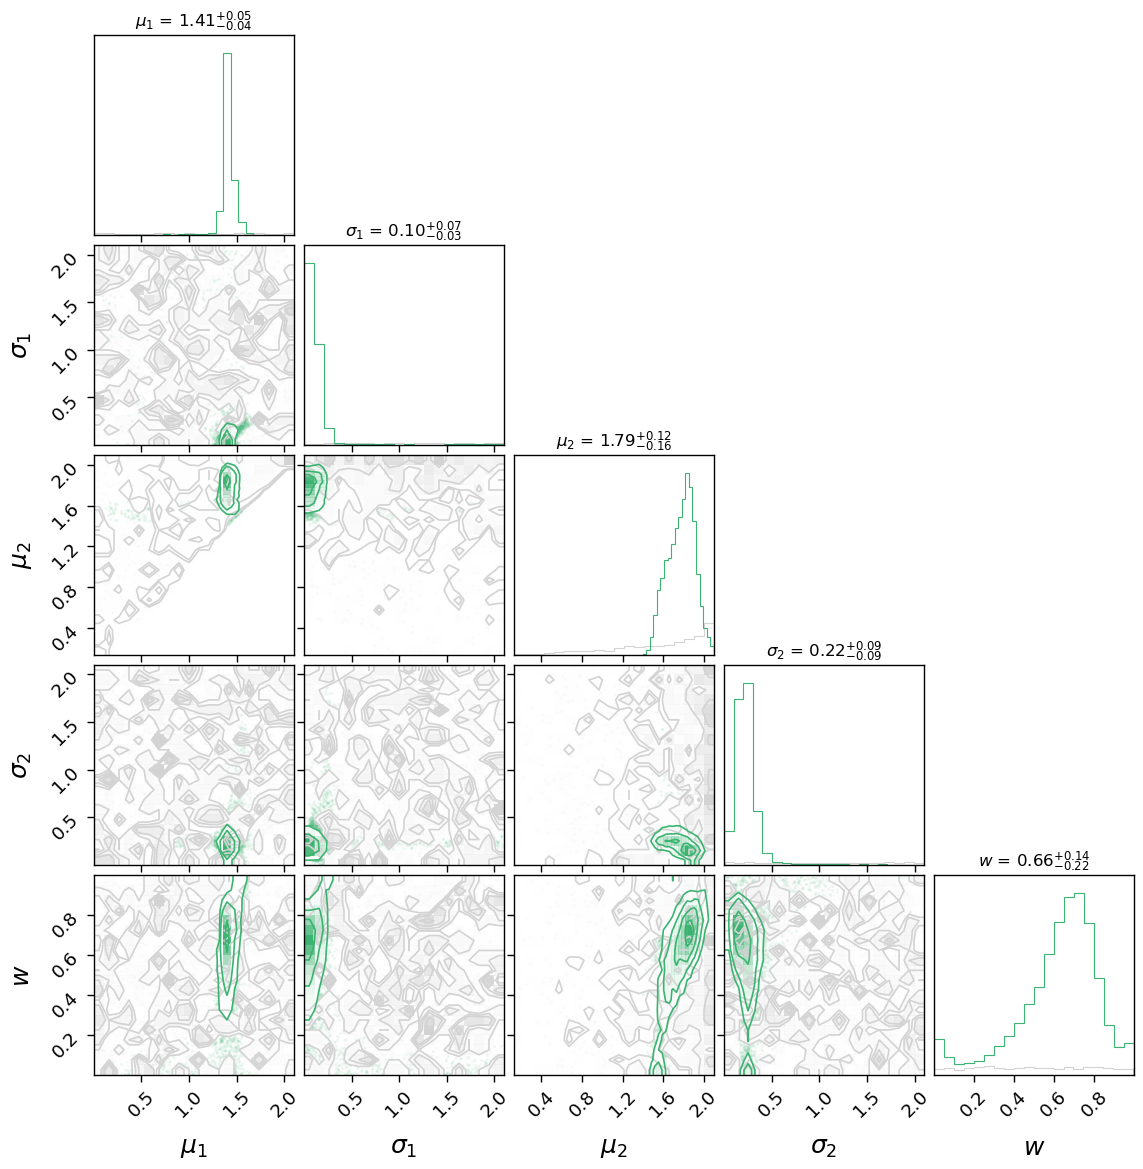

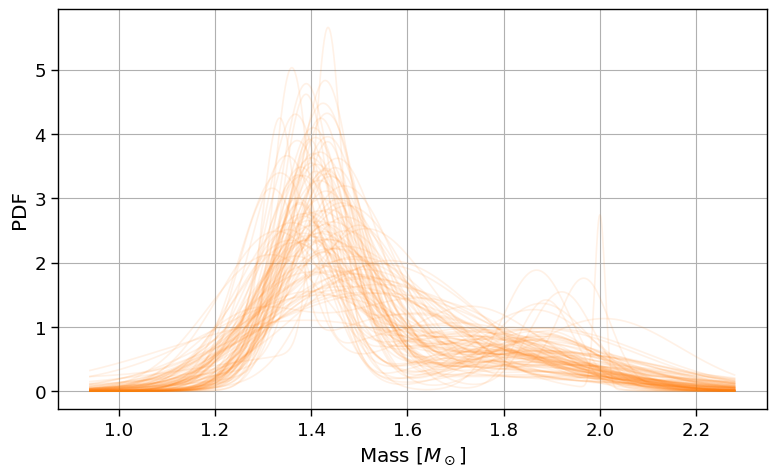

Double Gaussian (Uniform Prior):






In [ ]:
rng = random.PRNGKey(0)

# Fit single Gaussian - uniform prior
rng, rng_infer_single = random.split(rng)
mcmc_gaussian_uniform = run_inference(gaussian_uniform, NSWD_data, NSWD_data_err, rng_infer_single)
samples_gaussian_uniform= az.from_numpyro(mcmc_gaussian_uniform)

rng, rng_prior_single = random.split(rng)
prior_sampler = MCMC(NUTS(gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(rng_prior_single, NSWD_data, NSWD_data_err, prior=True)   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='lightgrey',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_gaussian_uniform,
    var_names=['mu', 'sigma'],
    labels=[r"$\mu$", r"$\sigma$"],
    color='mediumseagreen',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

plt.show()

plot_mass_distributions(mcmc_gaussian_uniform, "single", NSWD_data, label="NS-WD")

print("Single Gaussian (Uniform Prior):")

print()
print()
print()


# Fit two-component Gaussian - Uniform prior
rng, rng_infer_double = random.split(rng)
mcmc_double_uniform = run_inference(double_gaussian_uniform, NSWD_data, NSWD_data_err, rng_infer_double)
samples_double_uniform = az.from_numpyro(mcmc_double_uniform)

rng, rng_prior_double = random.split(rng)
prior_sampler = MCMC(NUTS(double_gaussian_uniform), num_warmup=1000, num_samples=1000, progress_bar = True)
prior_sampler.run(rng_prior_double, NSWD_data, NSWD_data_err, prior=True)   
prior_samples = prior_sampler.get_samples()

fig = corner.corner(
    prior_samples,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='lightgrey',
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)

corner.corner(
    samples_double_uniform,
    var_names=['mu1', 'sigma1', 'mu2', 'sigma2', 'weight'],
    labels=[r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"],
    color='mediumseagreen',
    fig=fig,
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs=dict(fontsize=18)
)
plt.show()

plot_mass_distributions(mcmc_double_uniform, "double", NSWD_data, label="NS-WD")

print("Double Gaussian (Uniform Prior):")  
print()
print()
print()
print()

In [ ]:
# save the fits for comparison with the other populations later
NSWD_corner_samples = samples_double_uniform
NSWDfit = mcmc_double_uniform
NSWDfit_samples = NSWDfit.get_samples()

NSWD_corner_samples = NSWDfit_samples

array([[<Axes: title={'center': 'log_L'}>,
        <Axes: title={'center': 'log_L'}>],
       [<Axes: title={'center': 'mu1'}>, <Axes: title={'center': 'mu1'}>],
       [<Axes: title={'center': 'mu2'}>, <Axes: title={'center': 'mu2'}>],
       [<Axes: title={'center': 'sigma1'}>,
        <Axes: title={'center': 'sigma1'}>],
       [<Axes: title={'center': 'sigma2'}>,
        <Axes: title={'center': 'sigma2'}>],
       [<Axes: title={'center': 'weight'}>,
        <Axes: title={'center': 'weight'}>]], dtype=object)

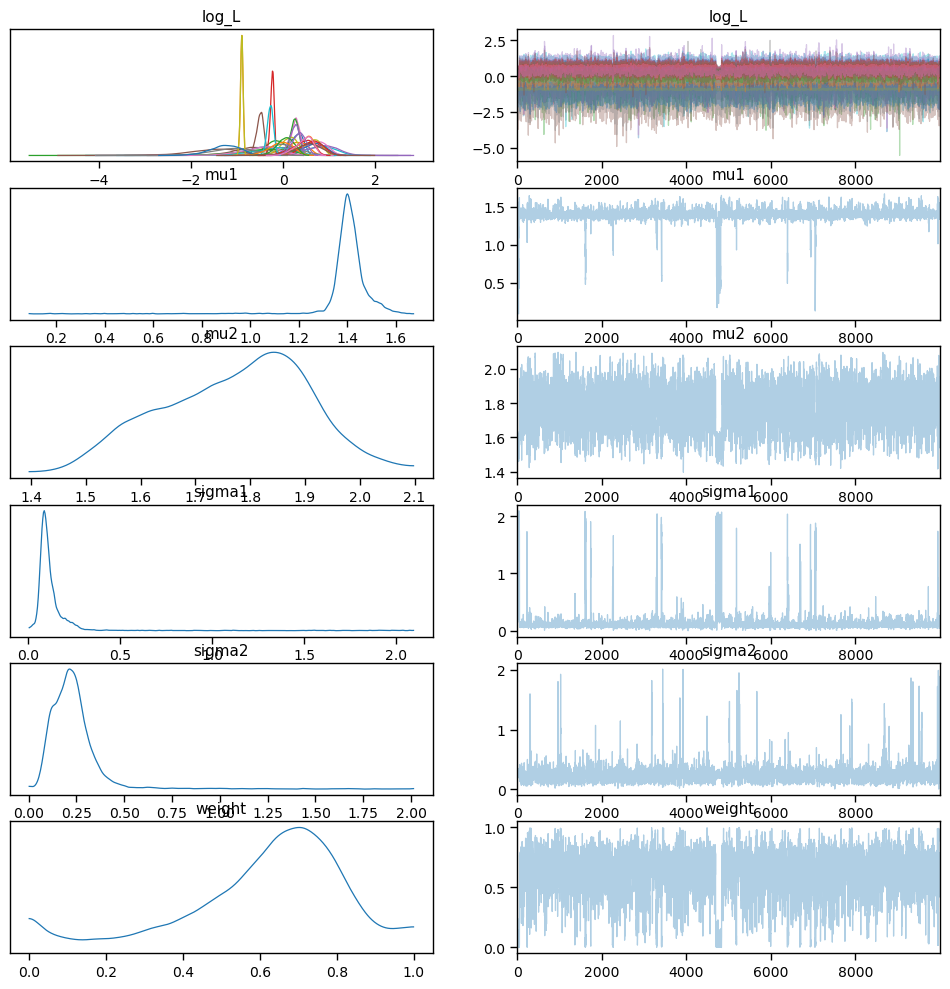

In [ ]:
az.plot_trace(NSWDfit)

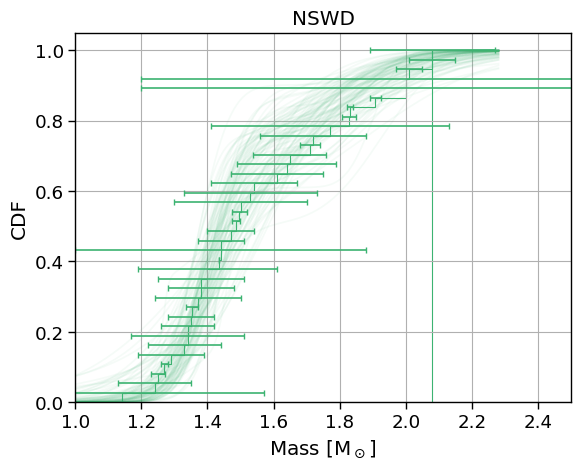

In [ ]:
# plot CDF of fit with data
NSWD_masses,NSWD_uerrors, NSWD_lerrors, NSWD_bins =plot_cdf(NSWD_data,NSWD_data_err,NSWD_data_err)


x = np.linspace(min(NSWD_data) - 0.2, max(NSWD_data) + 0.2, 1000)
for i in np.random.choice(len(NSWDfit_samples['mu1']), 100, replace=False):
    y = NSWDfit_samples['weight'][i] * scipy.stats.norm.cdf(
        x, loc=NSWDfit_samples['mu1'][i], scale=NSWDfit_samples['sigma1'][i]  
    ) + (1 - NSWDfit_samples['weight'][i]) * scipy.stats.norm.cdf(
        x, loc=NSWDfit_samples['mu2'][i], scale=NSWDfit_samples['sigma2'][i]  
    )
    plt.plot(x, y, alpha=0.05, color='mediumseagreen', label='NS-WD')


plt.stairs(np.array(range(len(NSWD_masses)+1))/len(NSWD_masses),NSWD_bins, alpha =1 ,color='mediumseagreen')
plt.errorbar(NSWD_masses, np.array(range(len(NSWD_masses)+1))[1:]/len(NSWD_masses), xerr = (NSWD_uerrors, NSWD_lerrors), color='mediumseagreen', ls = "None", capsize = 2)
plt.ylabel("CDF")
plt.xlabel("Mass [M$_\odot$]")
plt.title("NSWD")
plt.xlim(1.0, 2.5)
plt.grid()
plt.show()


# Comparison Tests

/var/folders/by/tlp8gdq17q72kgysbfmtlzp40000gn/T/ipykernel_60817/1208766924.py:50: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


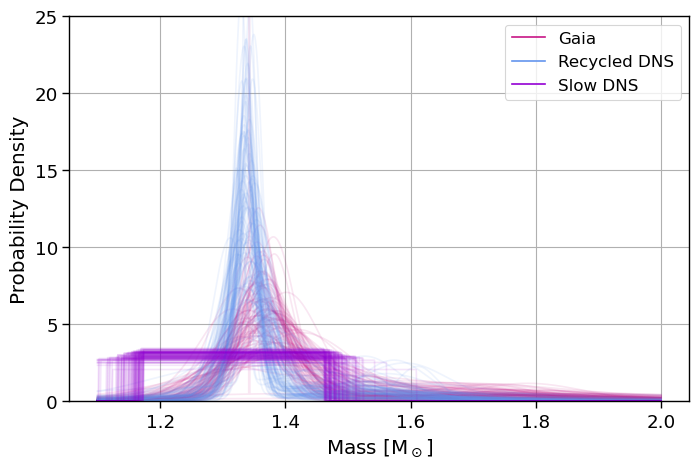

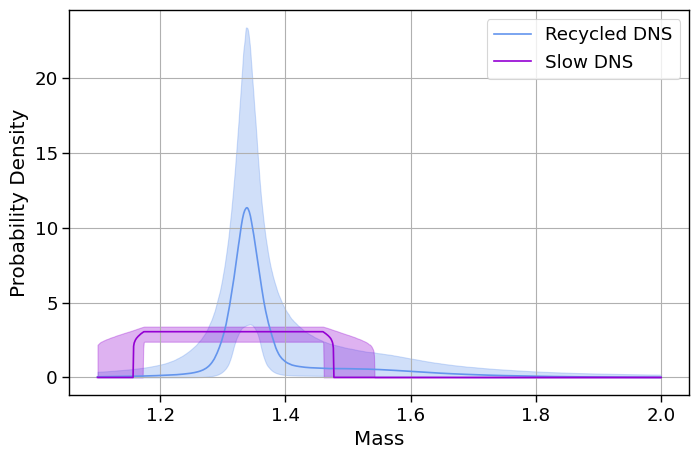

/var/folders/by/tlp8gdq17q72kgysbfmtlzp40000gn/T/ipykernel_60817/1208766924.py:156: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for handle in legend.legendHandles:


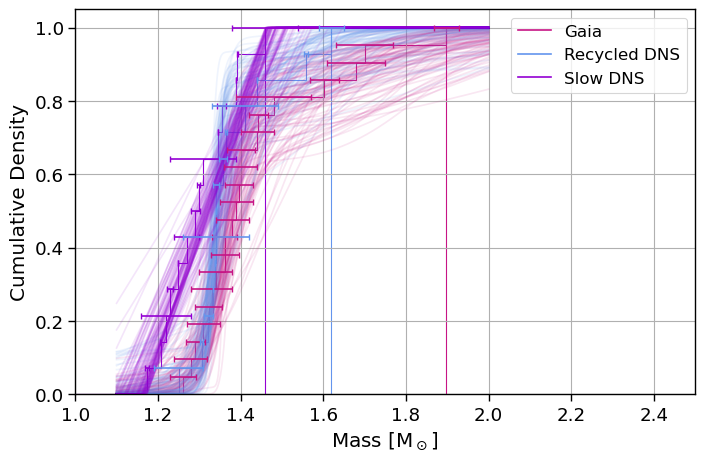

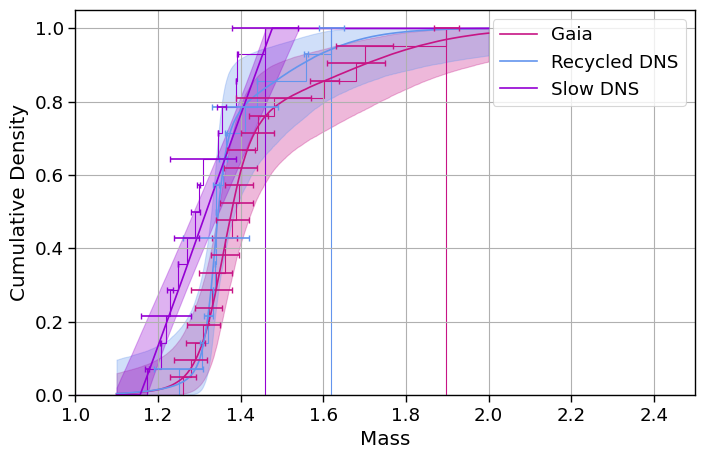

In [ ]:
###
# Plot the mass distributions of the recycled DNS and Gaia populations
###
plt.figure(figsize=(8,5))
x = np.linspace(1.1, 2, 1000)

# Gaia
plotN = 0
gaiaPPDs = []
for i in np.random.choice(len(gaiafit_samples['mu1']), 100, replace=False):
    y = gaiafit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=gaiafit_samples['mu1'][i], scale=gaiafit_samples['sigma1'][i]) +\
        (1 - gaiafit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=gaiafit_samples['mu2'][i], scale=gaiafit_samples['sigma2'][i])
    plt.plot(x, y, alpha=0.1, color='mediumvioletred', label='Gaia' if plotN == 0 else None)
    plotN += 1
    gaiaPPDs.append(y)

# Recycled DNS
plotN = 0
recycledDNSPPDs = []
for i in np.random.choice(len(recycledDNSfit_samples['mu1']), 100, replace=False):
    y = recycledDNSfit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=recycledDNSfit_samples['mu1'][i], scale=recycledDNSfit_samples['sigma1'][i]) +\
        (1 - recycledDNSfit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=recycledDNSfit_samples['mu2'][i], scale=recycledDNSfit_samples['sigma2'][i])
    plt.plot(x, y, alpha=0.1, color='cornflowerblue', label= 'Recycled DNS' if plotN == 0 else None)
    plotN += 1
    recycledDNSPPDs.append(y)

# NS-WD
# plotN = 0
# for i in np.random.choice(len(NSWDfit_samples['mu1']), 100, replace=False):
#     y = NSWDfit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=NSWDfit_samples['mu1'][i], scale=NSWDfit_samples['sigma1'][i]) +\
#         (1 - NSWDfit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=NSWDfit_samples['mu2'][i], scale=NSWDfit_samples['sigma2'][i])
#     plt.plot(x, y, alpha=0.1, color='mediumseagreen', label='NS-WD' if plotN == 0 else None)
#     plotN += 1

# Slow DNS
plotN = 0
low = slowDNSfit_samples[:, 0]    
high = slowDNSfit_samples[:, 1]
for i in np.random.choice(len(low), 100, replace=False):
    y = scipy.stats.uniform.pdf(x, loc=low[i], scale=high[i] - low[i])
    plt.plot(x, y, alpha=0.1, color='darkviolet', label='Slow DNS' if plotN == 0 else None)
    plotN += 1
    

plt.grid()
plt.ylabel("Probability Density")
plt.xlabel("Mass [M$_\odot$]")
plt.ylim(0,25)
legend = plt.legend(frameon=True, loc='best', fontsize=12)
for handle in legend.legendHandles:
    handle.set_alpha(1.0) 
plt.show()
#
#
#

###
# Plot credible bands instead of individual curves
###
gaiacurves = np.array([
    gaiafit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=gaiafit_samples['mu1'][i], scale=gaiafit_samples['sigma1'][i]) +
    (1 - gaiafit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=gaiafit_samples['mu2'][i], scale=gaiafit_samples['sigma2'][i])
    for i in range(len(gaiafit_samples['mu1']))
])

recycledDNScurves = np.array([
    recycledDNSfit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=recycledDNSfit_samples['mu1'][i], scale=recycledDNSfit_samples['sigma1'][i]) +
    (1 - recycledDNSfit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=recycledDNSfit_samples['mu2'][i], scale=recycledDNSfit_samples['sigma2'][i])
    for i in range(len(recycledDNSfit_samples['mu1']))
])

# NSWDcurves = np.array([
#     NSWDfit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=NSWDfit_samples['mu1'][i], scale=NSWDfit_samples['sigma1'][i]) +
#     (1 - NSWDfit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=NSWDfit_samples['mu2'][i], scale=NSWDfit_samples['sigma2'][i])
#     for i in range(len(NSWDfit_samples['mu1']))
# ])
slowcurves = np.array([
    scipy.stats.uniform.pdf(x, loc=low[i], scale=high[i] - low[i]) for i in range(len(low)) ])

plt.figure(figsize=(8,5))

# plt.plot(x, np.median(gaiacurves, axis=0), alpha=1, color='mediumvioletred', label='Gaia')
# plt.fill_between(x, np.percentile(gaiacurves, 5, axis=0), np.percentile(gaiacurves, 95, axis=0), alpha=0.3, color='mediumvioletred')

plt.plot(x, np.median(recycledDNScurves, axis=0), alpha=1, color='cornflowerblue', label='Recycled DNS')
plt.fill_between(x, np.percentile(recycledDNScurves, 5, axis=0), np.percentile(recycledDNScurves, 95, axis=0), alpha=0.3, color='cornflowerblue')

# plt.plot(x, np.median(NSWDcurves, axis=0), alpha=1, color='mediumseagreen', label='NS-WD')
# plt.fill_between(x, np.percentile(NSWDcurves, 5, axis=0), np.percentile(NSWDcurves, 95, axis=0), alpha=0.3, color='mediumseagreen')

plt.plot(x, np.median(slowcurves, axis=0), alpha=1, color='darkviolet', label='Slow DNS')
plt.fill_between(x, np.percentile(slowcurves, 5, axis=0), np.percentile(slowcurves, 95, axis=0), alpha=0.3, color='darkviolet')


plt.grid()
plt.xlabel("Mass")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

###
# Plot CDF of fit with data
###
plt.figure(figsize=(8,5))

# Gaia
plotN = 0
for i in np.random.choice(len(gaiafit_samples['mu1']), 100, replace=False):
    y = gaiafit_samples['weight'][i] * scipy.stats.norm.cdf(x, loc=gaiafit_samples['mu1'][i], scale=gaiafit_samples['sigma1'][i]) +\
        (1 - gaiafit_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=gaiafit_samples['mu2'][i], scale=gaiafit_samples['sigma2'][i])
    plt.plot(x, y, alpha=0.1, color='mediumvioletred', label='Gaia' if plotN == 0 else None)
    plotN += 1

# Recycled DNS
plotN = 0
for i in np.random.choice(len(recycledDNSfit_samples['mu1']), 100, replace=False):
    y = recycledDNSfit_samples['weight'][i] * scipy.stats.norm.cdf(x, loc=recycledDNSfit_samples['mu1'][i], scale=recycledDNSfit_samples['sigma1'][i]) +\
        (1 - recycledDNSfit_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=recycledDNSfit_samples['mu2'][i], scale=recycledDNSfit_samples['sigma2'][i])
    plt.plot(x, y, alpha=0.1, color='cornflowerblue', label= 'Recycled DNS' if plotN == 0 else None)
    plotN += 1

# NS-WD
# for i in np.random.choice(len(NSWDfit_samples['mu1']), 100, replace=False):
#     y = NSWDfit_samples['weight'][i] * scipy.stats.norm.cdf(x, loc=NSWDfit_samples['mu1'][i], scale=NSWDfit_samples['sigma1'][i]) +\
#         (1 - NSWDfit_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=NSWDfit_samples['mu2'][i], scale=NSWDfit_samples['sigma2'][i])
#     plt.plot(x, y, alpha=0.1, color='mediumseagreen', label='NS-WD' if plotN == 0 else None)
#     plotN += 1

# Slow DNS
plotN = 0
low = slowDNSfit_samples[:, 0]    
high = slowDNSfit_samples[:, 1]
for i in np.random.choice(len(low), 100, replace=False):
    y = scipy.stats.uniform.cdf(x, loc=low[i], scale=high[i] - low[i])
    plt.plot(x, y, alpha=0.1, color='darkviolet', label='Slow DNS' if plotN == 0 else None)
    plotN += 1
plt.stairs(np.array(range(len(slow_masses)+1))/len(slow_masses),slow_bins, alpha =1 ,color='darkviolet')
plt.errorbar(slow_masses, np.array(range(len(slow_masses)+1))[1:]/len(slow_masses), xerr = (slow_uerrors, slow_lerrors), color='darkviolet', ls = "None", capsize = 2)
    


plt.stairs(np.array(range(len(gaia_masses)+1))/len(gaia_masses),gaia_bins, alpha =1 ,color='mediumvioletred')
plt.errorbar(gaia_masses, np.array(range(len(gaia_masses)+1))[1:]/len(gaia_masses), xerr = (gaia_uerrors, gaia_lerrors), color='mediumvioletred', ls = "None", capsize = 2)

plt.stairs(np.array(range(len(DNS_masses)+1))/len(DNS_masses),DNS_bins, alpha =1 ,color='cornflowerblue')
plt.errorbar(DNS_masses, np.array(range(len(DNS_masses)+1))[1:]/len(DNS_masses), xerr = (DNS_uerrors, DNS_lerrors), color='cornflowerblue', ls = "None", capsize = 2)

# plt.stairs(np.array(range(len(NSWD_masses)+1))/len(NSWD_masses),NSWD_bins, alpha =1 ,color='mediumseagreen')
# plt.errorbar(NSWD_masses, np.array(range(len(NSWD_masses)+1))[1:]/len(NSWD_masses), xerr = (NSWD_uerrors, NSWD_lerrors), color='mediumseagreen', ls = "None", capsize = 2)

plt.xlim(1.0, 2.5)
plt.grid()
plt.ylabel("Cumulative Density")
plt.xlabel("Mass [M$_\odot$]")
legend = plt.legend(frameon=True, loc='best', fontsize=12)
for handle in legend.legendHandles:
    handle.set_alpha(1.0)  
plt.show()
#
#
#
# Plot credible bands instead of individual curves
gaiacurves = np.array([
    gaiafit_samples['weight'][i] * scipy.stats.norm.cdf(x, loc=gaiafit_samples['mu1'][i], scale=gaiafit_samples['sigma1'][i]) +
    (1 - gaiafit_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=gaiafit_samples['mu2'][i], scale=gaiafit_samples['sigma2'][i])
    for i in range(len(gaiafit_samples['mu1']))
])

recycledDNScurves = np.array([
    recycledDNSfit_samples['weight'][i] * scipy.stats.norm.cdf(x, loc=recycledDNSfit_samples['mu1'][i], scale=recycledDNSfit_samples['sigma1'][i]) +
    (1 - recycledDNSfit_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=recycledDNSfit_samples['mu2'][i], scale=recycledDNSfit_samples['sigma2'][i])
    for i in range(len(recycledDNSfit_samples['mu1']))
])

# NSWDcurves = np.array([
#     NSWDfit_samples['weight'][i] * scipy.stats.norm.cdf(x, loc=NSWDfit_samples['mu1'][i], scale=NSWDfit_samples['sigma1'][i]) +
#     (1 - NSWDfit_samples['weight'][i]) * scipy.stats.norm.cdf(x, loc=NSWDfit_samples['mu2'][i], scale=NSWDfit_samples['sigma2'][i])
#     for i in range(len(NSWDfit_samples['mu1']))
# ])

slowcurves = np.array([
    scipy.stats.uniform.cdf(x, loc=low[i], scale=high[i] - low[i]) for i in range(len(low)) ])


# Plot median and percentile bands
plt.figure(figsize=(8,5))
plt.plot(x, np.median(gaiacurves, axis=0), alpha=1, color='mediumvioletred', label='Gaia')
plt.fill_between(x, np.percentile(gaiacurves, 5, axis=0), np.percentile(gaiacurves, 95, axis=0), alpha=0.3, color='mediumvioletred')

plt.plot(x, np.median(recycledDNScurves, axis=0), alpha=1, color='cornflowerblue', label='Recycled DNS')
plt.fill_between(x, np.percentile(recycledDNScurves, 5, axis=0), np.percentile(recycledDNScurves, 95, axis=0), alpha=0.3, color='cornflowerblue')

# plt.plot(x, np.median(NSWDcurves, axis=0), alpha=1, color='mediumseagreen', label='NS-WD')
# plt.fill_between(x, np.percentile(NSWDcurves, 5, axis=0), np.percentile(NSWDcurves, 95, axis=0), alpha=0.3, color='mediumseagreen')

plt.plot(x, np.median(slowcurves, axis=0), alpha=1, color='darkviolet', label='Slow DNS')
plt.fill_between(x, np.percentile(slowcurves, 5, axis=0), np.percentile(slowcurves, 95, axis=0), alpha=0.3, color='darkviolet')

plt.stairs(np.array(range(len(gaia_masses)+1))/len(gaia_masses),gaia_bins, alpha =1 ,color='mediumvioletred')
plt.errorbar(gaia_masses, np.array(range(len(gaia_masses)+1))[1:]/len(gaia_masses), xerr = (gaia_uerrors, gaia_lerrors), color='mediumvioletred', ls = "None", capsize = 2)

plt.stairs(np.array(range(len(DNS_masses)+1))/len(DNS_masses),DNS_bins, alpha =1 ,color='cornflowerblue')
plt.errorbar(DNS_masses, np.array(range(len(DNS_masses)+1))[1:]/len(DNS_masses), xerr = (DNS_uerrors, DNS_lerrors), color='cornflowerblue', ls = "None", capsize = 2)

# plt.stairs(np.array(range(len(NSWD_masses)+1))/len(NSWD_masses),NSWD_bins, alpha =1 ,color='mediumseagreen')
# plt.errorbar(NSWD_masses, np.array(range(len(NSWD_masses)+1))[1:]/len(NSWD_masses), xerr = (NSWD_uerrors, NSWD_lerrors), color='mediumseagreen', ls = "None", capsize = 2)

plt.stairs(np.array(range(len(slow_masses)+1))/len(slow_masses),slow_bins, alpha =1 ,color='darkviolet')
plt.errorbar(slow_masses, np.array(range(len(slow_masses)+1))[1:]/len(slow_masses), xerr = (slow_uerrors, slow_lerrors), color='darkviolet', ls = "None", capsize = 2)

plt.grid()
plt.xlabel("Mass")
plt.ylabel("Cumulative Density")
plt.xlim(1.0, 2.5)
plt.legend()
plt.show()

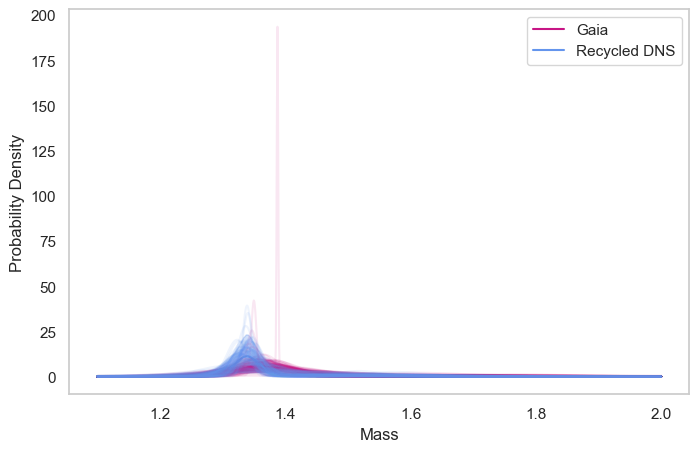

In [184]:
###
# Plot the mass distributions of the recycled DNS and Gaia populations
###
plt.figure(figsize=(8,5))
x = np.linspace(1.1, 2, 1000)

###
# Plot credible bands instead of individual curves
###
gaiacurves = np.array([
    gaiafit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=gaiafit_samples['mu1'][i], scale=gaiafit_samples['sigma1'][i]) +
    (1 - gaiafit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=gaiafit_samples['mu2'][i], scale=gaiafit_samples['sigma2'][i])
    for i in range(len(gaiafit_samples['mu1']))
])

recycledDNScurves = np.array([
    recycledDNSfit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=recycledDNSfit_samples['mu1'][i], scale=recycledDNSfit_samples['sigma1'][i]) +
    (1 - recycledDNSfit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=recycledDNSfit_samples['mu2'][i], scale=recycledDNSfit_samples['sigma2'][i])
    for i in range(len(recycledDNSfit_samples['mu1']))
])

plt.plot(x, np.median(gaiacurves, axis=0), alpha=1, color='mediumvioletred', label='Gaia')
plt.fill_between(x, np.percentile(gaiacurves, 5, axis=0), np.percentile(gaiacurves, 95, axis=0), alpha=0.3, color='mediumvioletred')

plt.plot(x, np.median(recycledDNScurves, axis=0), alpha=1, color='cornflowerblue', label='Recycled DNS')
plt.fill_between(x, np.percentile(recycledDNScurves, 5, axis=0), np.percentile(recycledDNScurves, 95, axis=0), alpha=0.3, color='cornflowerblue')


# Gaia
plotN = 0
for i in np.random.choice(len(gaiafit_samples['mu1']), 100, replace=False):
    y = gaiafit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=gaiafit_samples['mu1'][i], scale=gaiafit_samples['sigma1'][i]) +\
        (1 - gaiafit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=gaiafit_samples['mu2'][i], scale=gaiafit_samples['sigma2'][i])
    plt.plot(x, y, alpha=0.1, color='mediumvioletred', label='_Gaia' if plotN == 0 else None)
    plotN += 1

# Recycled DNS
plotN = 0
for i in np.random.choice(len(recycledDNSfit_samples['mu1']), 100, replace=False):
    y = recycledDNSfit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=recycledDNSfit_samples['mu1'][i], scale=recycledDNSfit_samples['sigma1'][i]) +\
        (1 - recycledDNSfit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=recycledDNSfit_samples['mu2'][i], scale=recycledDNSfit_samples['sigma2'][i])
    plt.plot(x, y, alpha=0.1, color='cornflowerblue', label= '_Recycled DNS' if plotN == 0 else None)
    plotN += 1

#
#

plt.grid()
plt.xlabel("Mass")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

mu1 - DNS: 1.34 ± 0.044 (0.08, 0.03)
mu1 - Gaia: 1.36 ± 0.038 (0.03, 0.04)
sigma1 - DNS: 0.02 ± 0.239 (0.01, 0.47)
sigma1 - Gaia: 0.05 ± 0.122 (0.03, 0.07)
mu2 - DNS: 1.50 ± 0.136 (0.16, 0.28)
mu2 - Gaia: 1.65 ± 0.141 (0.22, 0.25)
sigma2 - DNS: 0.14 ± 0.275 (0.12, 0.59)
sigma2 - Gaia: 0.22 ± 0.211 (0.13, 0.41)
weight - DNS: 0.70 ± 0.212 (0.51, 0.21)
weight - Gaia: 0.74 ± 0.148 (0.29, 0.17)


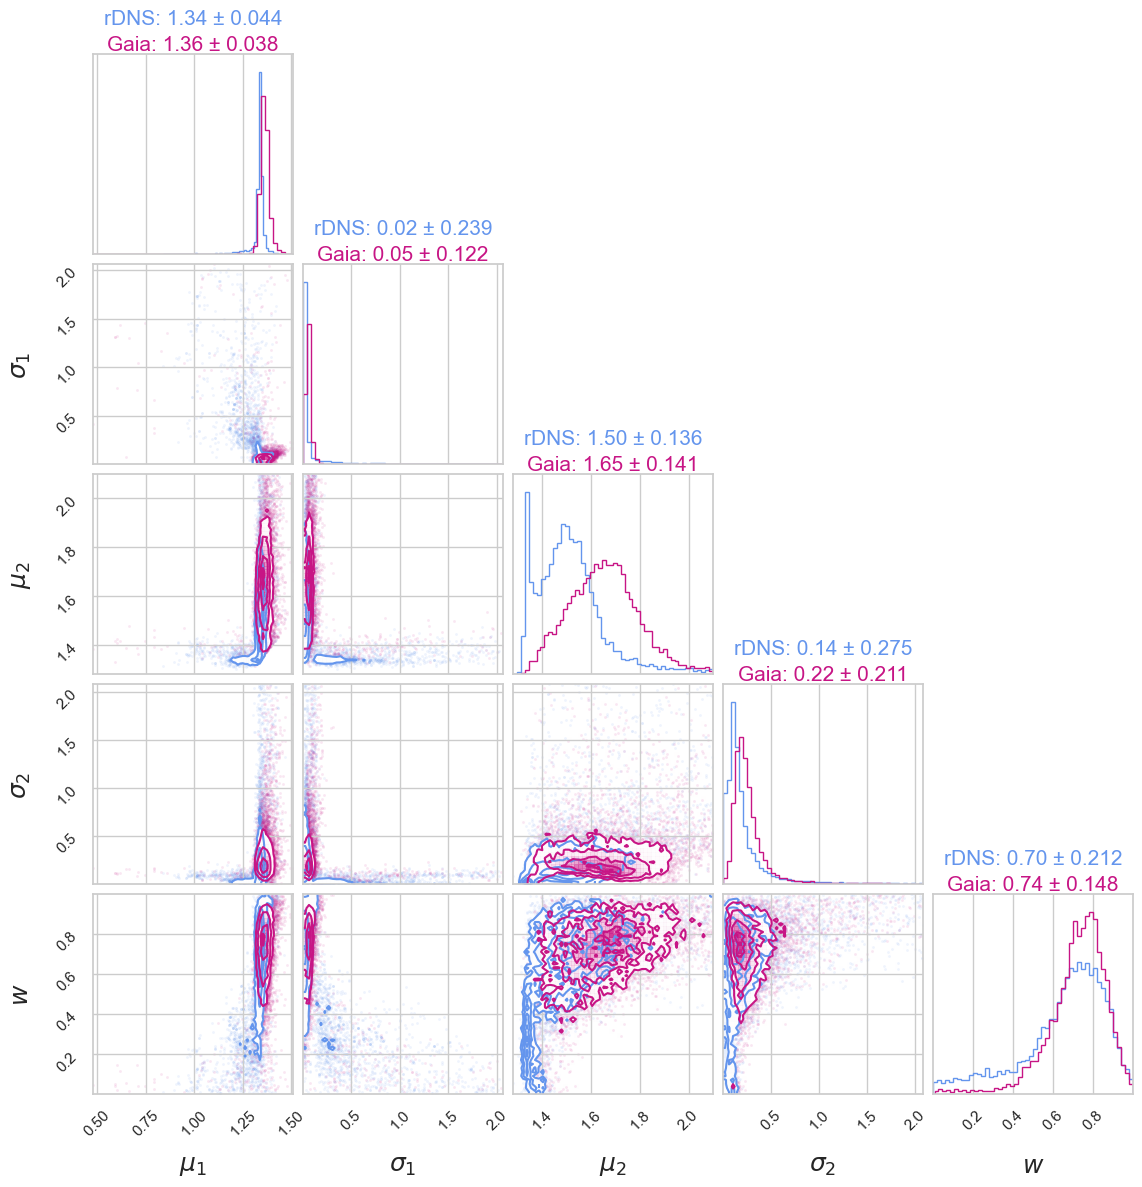

In [185]:
### Plot overlapping corner plots from different populations

# Variables
params = ['mu1', 'sigma1', 'mu2', 'sigma2', 'weight']
labels = [r"$\mu_1$", r"$\sigma_1$", r"$\mu_2$", r"$\sigma_2$", r"$w$"]

fig = corner.corner(
    DNS_corner_samples,
    var_names=params,
    labels=labels,
    color='cornflowerblue',
    show_titles=False,
    label_kwargs=dict(fontsize=18),
    bins=50
)

corner.corner(
    gaia_corner_samples,
    var_names=params,
    labels=labels,
    color='mediumvioletred',
    fig=fig,
    show_titles=False,
    label_kwargs=dict(fontsize=18),
    bins=50
)

# corner.corner(
#     NSWD_corner_samples,
#     var_names=params,
#     labels=labels,
#     color='mediumseagreen',
#     fig=fig,
#     show_titles=False,
#     label_kwargs=dict(fontsize=18)
# )


# Add in title manually
ndim = len(params)
axes = np.array(fig.axes).reshape((ndim, ndim))

for i, param in enumerate(params):
    ax = axes[i, i]

    # Compute summary stats
    median_dns = np.median(DNS_corner_samples.posterior[param])
    std_dns = np.std(DNS_corner_samples.posterior[param])
    # median_nswd = np.median(NSWD_corner_samples[param])
    # std_nswd = np.std(NSWD_corner_samples[param])
    median_gaia = np.median(gaia_corner_samples.posterior[param])
    std_gaia = np.std(gaia_corner_samples.posterior[param])

    lower_percentile = np.percentile(DNS_corner_samples.posterior[param], 5)
    upper_percentile = np.percentile(DNS_corner_samples.posterior[param], 95)
    lower_percentile_gaia = np.percentile(gaia_corner_samples.posterior[param], 5)
    upper_percentile_gaia = np.percentile(gaia_corner_samples.posterior[param], 95)

    print(f"{param} - DNS: {median_dns:.2f} ± {std_dns:.3f} ({median_dns-lower_percentile:.2f}, {upper_percentile-median_dns:.2f})")
    print(f"{param} - Gaia: {median_gaia:.2f} ± {std_gaia:.3f} ({median_gaia-lower_percentile_gaia:.2f}, {upper_percentile_gaia-median_gaia:.2f})")
    # print(f"{param} - NSWD: {


    # Add DNS title (top line)
    ax.text(0.5, 1.13,
            f"rDNS: {median_dns:.2f} ± {std_dns:.3f}",
            fontsize=15, color='cornflowerblue',
            ha='center', va='bottom', transform=ax.transAxes)
    
    # Add NSWD title 
    # ax.text(0.5, 1.26,
    #         f"NSWD: {median_nswd:.2f} ± {std_nswd:.3f}",
    #         fontsize=15, color='mediumseagreen',
    #         ha='center', va='bottom', transform=ax.transAxes)

    # Add Gaia title
    ax.text(0.5, 1.00,
            f"Gaia: {median_gaia:.2f} ± {std_gaia:.3f}",
            fontsize=15, color='mediumvioletred',
            ha='center', va='bottom', transform=ax.transAxes)


plt.savefig("corner_plot.png", dpi=600, bbox_inches='tight')
plt.show()

## Statistical Comparison

In [215]:
### What percentage of the time is gaia mu2 greater than recycled mu2?
gaia_mu2 = gaiafit_samples['mu2']
recycled_mu2 = recycledDNSfit_samples['mu2']

sampleN = 10000
gaia_samples = np.random.choice(gaia_mu2, size=sampleN, replace=False)
recycled_samples = np.random.choice(recycled_mu2, size=sampleN, replace=False)

# Compare element-wise: how often is Gaia's mu2 > Recycled's mu1
greater_count = np.sum(gaia_samples > recycled_samples)
percentage_greater = (greater_count / sampleN) * 100

print(f"Percentage of times Gaia mu2 > Recycled mu2 (from 21 draws): {percentage_greater:.2f}%")

Percentage of times Gaia mu2 > Recycled mu2 (from 21 draws): 77.59%


Jensen-Shannon Divergence: 0.0458


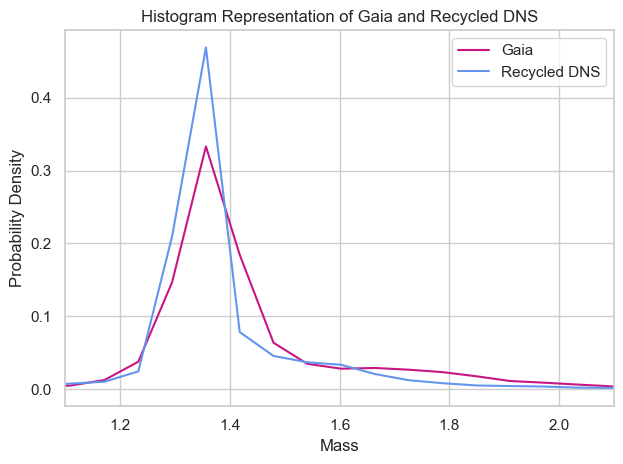

In [216]:
from scipy.spatial.distance import jensenshannon
import numpy as np
import matplotlib.pyplot as plt

def sample_from_double_gaussian(samples, size):
    """Sample from a 2-Gaussian mixture given posterior samples."""
    idxs = np.random.choice(len(samples['mu1']), size, replace=True)
    draws = []
    for i in idxs:
        if np.random.rand() < samples['weight'][i]:
            draw = np.random.normal(samples['mu1'][i], samples['sigma1'][i])
        else:
            draw = np.random.normal(samples['mu2'][i], samples['sigma2'][i])
        draws.append(draw)
    return np.array(draws)

# Draw samples from each posterior predictive distribution
n_samples = 10000
gaia_samples = sample_from_double_gaussian(gaiafit_samples, n_samples)
recycled_dns_samples = sample_from_double_gaussian(recycledDNSfit_samples, n_samples)

# Define a common bin range
all_samples = np.concatenate([gaia_samples, recycled_dns_samples])
bins = 100
hist_range = (all_samples.min(), all_samples.max())

# Compute histograms (PDFs)
hist_gaia, bin_edges = np.histogram(gaia_samples, bins=bins, range=hist_range, density=True)
hist_dns, _ = np.histogram(recycled_dns_samples, bins=bins, range=hist_range, density=True)

# Normalize to probability distributions
hist_gaia /= np.sum(hist_gaia)
hist_dns /= np.sum(hist_dns)

# Compute Jensen-Shannon divergence (scipy returns sqrt(JSD), so square it)
jsd_value = jensenshannon(hist_gaia, hist_dns, base = 2) ** 2
print(f"Jensen-Shannon Divergence: {jsd_value:.4f}")

# Optional: plot the histograms
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
plt.plot(bin_centers, hist_gaia, label='Gaia', color='mediumvioletred')
plt.plot(bin_centers, hist_dns, label='Recycled DNS', color='cornflowerblue')
plt.xlabel("Mass")
plt.ylabel("Probability Density")
plt.title("Histogram Representation of Gaia and Recycled DNS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(1.1,2.1)
plt.show()

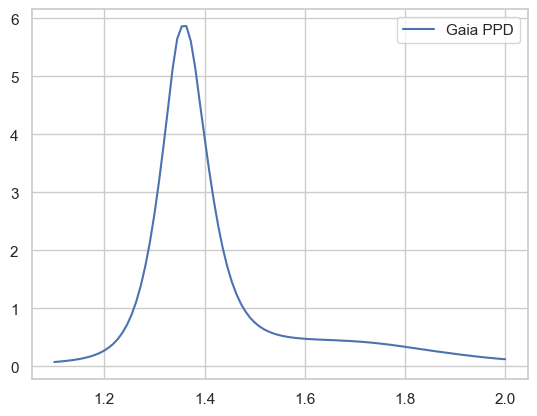

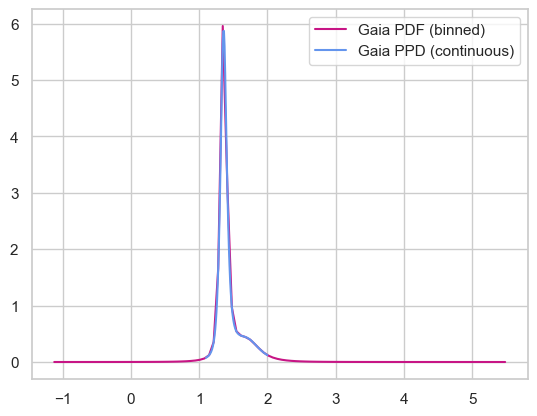

In [182]:
x = np.linspace(1.1,2,100) #0.5 * (bin_edges[:-1] + bin_edges[1:])  # same x for both
xhist = 0.5 * (bin_edges[:-1] + bin_edges[1:])

gaiacurves = np.array([
    gaiafit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=gaiafit_samples['mu1'][i], scale=gaiafit_samples['sigma1'][i]) +
    (1 - gaiafit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=gaiafit_samples['mu2'][i], scale=gaiafit_samples['sigma2'][i])
    for i in range(len(gaiafit_samples['mu1']))
])

# gaiacurves_at_bins = np.array([
#     gaiafit_samples['weight'][i] * scipy.stats.norm.pdf(xhist, loc=gaiafit_samples['mu1'][i], scale=gaiafit_samples['sigma1'][i]) +
#     (1 - gaiafit_samples['weight'][i]) * scipy.stats.norm.pdf(xhist, loc=gaiafit_samples['mu2'][i], scale=gaiafit_samples['sigma2'][i])
#     for i in range(len(gaiafit_samples['mu1']))
# ])

# # Normalize to make it a probability distribution (discrete)
# pdf = np.mean(gaiacurves_at_bins, axis=0)
# pdf /= np.sum(pdf)

#plt.plot(xhist, pdf, label='Gaia PDF', color='mediumvioletred')
plt.plot(x, np.mean(gaiacurves, axis=0), label='Gaia PPD')
#plt.xlim(-1,5)
plt.legend()
plt.show()


# For continuous mean of PDFs
ppd = np.mean(gaiacurves, axis=0)
#ppd /= np.trapz(ppd, x)  # Normalizes the area under the curve

# For discretized bin-based PDF
pdf = np.mean(gaiacurves_at_bins, axis=0)
#bin_width = bin_edges[1] - bin_edges[0]
#pdf /= (np.sum(pdf) * bin_width)  # Normalize so total probability sums to 1

# Plot
plt.plot(xhist, pdf, label='Gaia PDF (binned)', color='mediumvioletred')
plt.plot(x, ppd, label='Gaia PPD (continuous)', color='cornflowerblue')
plt.legend()
plt.grid(True)
plt.show()

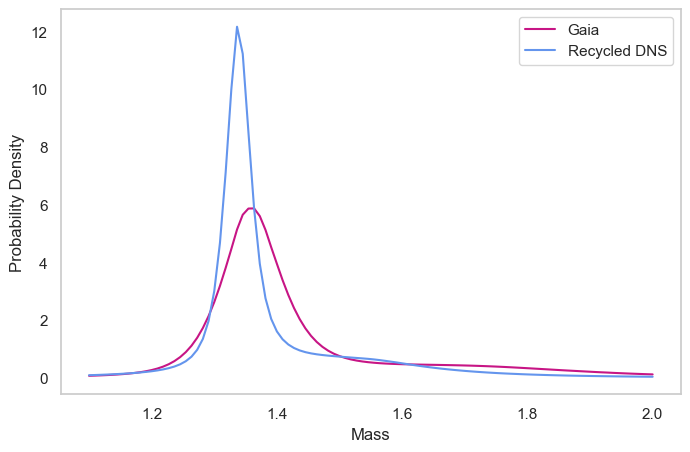

In [175]:
###
# Plot the mass distributions of the recycled DNS and Gaia populations
###
plt.figure(figsize=(8,5))
x = np.linspace(1.1, 2, 100)

###
# Plot credible bands instead of individual curves
###
gaiacurves = np.array([
    gaiafit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=gaiafit_samples['mu1'][i], scale=gaiafit_samples['sigma1'][i]) +
    (1 - gaiafit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=gaiafit_samples['mu2'][i], scale=gaiafit_samples['sigma2'][i])
    for i in range(len(gaiafit_samples['mu1']))
])

recycledDNScurves = np.array([
    recycledDNSfit_samples['weight'][i] * scipy.stats.norm.pdf(x, loc=recycledDNSfit_samples['mu1'][i], scale=recycledDNSfit_samples['sigma1'][i]) +
    (1 - recycledDNSfit_samples['weight'][i]) * scipy.stats.norm.pdf(x, loc=recycledDNSfit_samples['mu2'][i], scale=recycledDNSfit_samples['sigma2'][i])
    for i in range(len(recycledDNSfit_samples['mu1']))
])
plt.plot(x, np.mean(gaiacurves, axis=0), alpha=1, color='mediumvioletred', label='Gaia')
plt.plot(x, np.mean(recycledDNScurves, axis=0), alpha=1, color='cornflowerblue', label='Recycled DNS')

plt.grid()
plt.xlabel("Mass")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

JSD: 0.0622
1.0


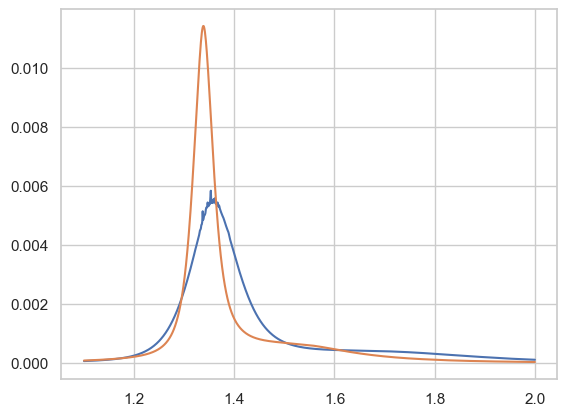

In [219]:
dx = 1# np.diff(x)[0]
p = np.mean(gaiacurves, axis=0)*dx/ np.sum(np.mean(gaiacurves, axis=0)*dx)
q =  np.mean(recycledDNScurves, axis=0)*dx / np.sum( np.mean(recycledDNScurves, axis=0)*dx)

# Compute squared Jensen-Shannon divergence
jsd = jensenshannon(p, q, base=2)**2
print(f"JSD: {jsd:.4f}")

print(np.sum(p))
plt.plot(x,p)
plt.plot(x,q)
plt.show()

Median JSD: 0.0496
90% Credible Limit for JSD: 0.0601


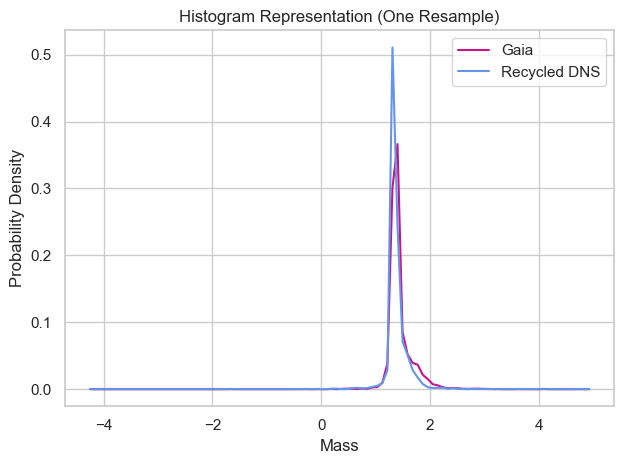

In [134]:
from scipy.spatial.distance import jensenshannon
import numpy as np
import matplotlib.pyplot as plt

def sample_from_double_gaussian(samples, size):
    """Sample from a 2-Gaussian mixture given posterior samples."""
    idxs = np.random.choice(len(samples['mu1']), size, replace=True)
    draws = []
    for i in idxs:
        if np.random.rand() < samples['weight'][i]:
            draw = np.random.normal(samples['mu1'][i], samples['sigma1'][i])
        else:
            draw = np.random.normal(samples['mu2'][i], samples['sigma2'][i])
        draws.append(draw)
    return np.array(draws)

# Parameters
n_samples = 5000
n_resamples = 1000  # Number of posterior predictive comparisons
bins = 100

jsd_values = []

# Resample and compute JSDs
for _ in range(n_resamples):
    gaia_samples = sample_from_double_gaussian(gaiafit_samples, n_samples)
    dns_samples = sample_from_double_gaussian(recycledDNSfit_samples, n_samples)

    # Histogram setup
    all_samples = np.concatenate([gaia_samples, dns_samples])
    hist_range = (all_samples.min(), all_samples.max())

    hist_gaia, bin_edges = np.histogram(gaia_samples, bins=bins, range=hist_range, density=True)
    hist_dns, _ = np.histogram(dns_samples, bins=bins, range=hist_range, density=True)

    # Normalize
    hist_gaia /= np.sum(hist_gaia)
    hist_dns /= np.sum(hist_dns)

    # Compute squared JSD
    jsd = jensenshannon(hist_gaia, hist_dns, base=2) ** 2
    jsd_values.append(jsd)

# Compute median and 90% upper credible limit
jsd_values = np.array(jsd_values)
median_jsd = np.median(jsd_values)
upper_90_jsd = np.percentile(jsd_values, 90)

print(f"Median JSD: {median_jsd:.4f}")
print(f"90% Credible Limit for JSD: {upper_90_jsd:.4f}")

# Optional: plot final comparison (one draw)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
plt.plot(bin_centers, hist_gaia, label='Gaia', color='mediumvioletred')
plt.plot(bin_centers, hist_dns, label='Recycled DNS', color='cornflowerblue')
plt.xlabel("Mass")
plt.ylabel("Probability Density")
plt.title("Histogram Representation (One Resample)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Two disjoint distributions
P = np.array([1, 0])
Q = np.array([0, 1])

jsd_sqrt = jensenshannon(P, Q, base = 2)  # returns 1.0
jsd = jsd_sqrt**2 
print(jsd)

1.0


In [220]:
from scipy.stats import wasserstein_distance
n_draws = 1000
n_samples = 5000 

wass_dists = []
for _ in range(n_draws):
    gaia_draw = sample_from_double_gaussian(gaiafit_samples, n_samples)
    recycled_draw = sample_from_double_gaussian(recycledDNSfit_samples, n_samples)
    d = wasserstein_distance(gaia_draw, recycled_draw)
    wass_dists.append(d)

wass_dists = np.array(wass_dists)

# Compute the 90% credible upper limit (i.e., the 90th percentile)
upper_limit = np.percentile(wass_dists, 90)

print(f"90% credible upper limit on Wasserstein distance: {upper_limit:.4f}")

90% credible upper limit on Wasserstein distance: 0.0592
